<a href="https://colab.research.google.com/github/Sautramani/Pandas-Numpy/blob/ASSIGNMENT_1_ML/MT26141_a1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1

## ✅ Rename the filename with your roll number. E.g., if your roll number is `MT24003`, then rename the file `MT24003_a1.ipynb` before submitting.

## ✅ Write code **only** in the sections marked with `# YOUR CODE HERE`. You cannot write code anywhere else.

## ✅ Download and extract `data.zip` next to this notebook. If you extract it correctly, you will have a `data` folder next to this notebook.

## ❌ Do not modify any other function or class definitions. Doing so may cause the autograder to fail while evaluating your submission, resulting in zero marks.

## ❌ Do not delete or add cells. This may cause the autograder to fail. Even if a cell is empty, do **not** delete it.

## ❌ Do not install or import any additional libraries. You should be able to solve all questions using only the libraries imported below.

In [119]:
# Required Libraries
import zipfile,os,glob,scipy,librosa,cv2,random,time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
from itertools import combinations

# `q1`: Loading and Analyzing RAVDESS (Audio) and FER2013 (Image) Datasets

In this question, you will build **dataloaders for two separate datasets** used throughout this assignment:

1. **RAVDESS** — used for audio (speech) emotion recognition. You are given a zip file which, once extracted, contains folders `Actor_01` to `Actor_24`, each containing `.wav` audio files.
2. **FER2013** — used for image emotion recognition. You are given a zip file which, once extracted, contains a `train` folder with subfolders named after emotions (e.g., `angry`, `happy`, `sad`, ...), each containing `.jpg` grayscale face images. We will only use the `train` folder in this assignment; ignore `test`.

The **unzip** code is already provided for both the datasets.

---

## Part A: RAVDESS Audio Metadata

RAVDESS filenames follow a 7-part numeric code, for example:

```text
Filename: 03-01-06-01-02-01-12.wav

03 = Modality      -> Audio-only
01 = Vocal channel -> Speech
06 = Emotion       -> Fearful
01 = Intensity     -> Normal
02 = Statement     -> "Dogs are sitting by the door"
01 = Repetition    -> 1st repetition
12 = Actor          -> Actor 12 (even number -> Female)
```

The **actor ID's parity** determines gender: odd actor IDs are male, even actor IDs are female.

You must implement:

1. `parse_ravdess_filename(filename)`  
   - Input: a filename string, e.g. `"03-01-06-01-02-01-12.wav"`.  
   - Output: a dict with keys: `modality_code`, `modality_label`, `vocal_channel_code`, `vocal_channel_label`, `emotion_code`, `emotion_label`, `intensity_code`, `intensity_label`, `statement_code`, `statement_text`, `repetition_code`, `actor_code`, `gender_label` (`"male"` or `"female"`, based on parity of `actor_code`).

2. `build_ravdess_metadata(ravdess_root_dir)`  
   - Input: path to the extracted RAVDESS root folder, which directly contains `Actor_01`, `Actor_02`, ..., `Actor_24` subfolders.  
   - Process: recursively walks through every `Actor_XX` folder, applies `parse_ravdess_filename` to every `.wav` file found, and adds a `filepath` field.  
   - Output: a Pandas DataFrame with one row per audio file, acting as the metadata table (since no CSV is provided).

3. `load_audio(path_to_audio_file)`  
   - Input: path to a `.wav` file.  
   - Process: loads the waveform using `librosa.load` with the original sampling rate (`sr=None`).  
   - Output: `(sr, audio)` — sampling rate and 1D NumPy array of samples.

4. `plot_ravdess_emotion_counts(metadata_df)`  
   - Plots a bar chart of the number of audio files per `emotion_label`.

5. `plot_ravdess_gender_counts(metadata_df)`  
   - Plots a bar chart of the number of audio files per `gender_label`.

---

## Part B: FER2013 Image Metadata

FER2013 (train split only) is organized as:

```text
fer2013/
    train/
        angry/
            im0.jpg
            im1.jpg
            ...
        happy/
            ...
        sad/
            ...
        ...
```

You must implement:

6. `build_fer2013_metadata(fer2013_train_dir)`  
   - Input: path to the `train` folder of FER2013 (containing one subfolder per emotion).  
   - Process: recursively walks through every emotion subfolder, and for every `.jpg` file records `filepath` and `emotion_label` (the subfolder name).  
   - Output: a Pandas DataFrame with columns `filepath`, `emotion_label`.

7. `load_image(path_to_image_file)`  
   - Input: path to a `.jpg` image.  
   - Process: loads the image using `cv2.imread` (grayscale is fine, FER2013 images are grayscale) and converts to a NumPy array.  
   - Output: a 2D (or 3D) NumPy array representing the image.

8. `plot_fer2013_emotion_counts(metadata_df)`  
   - Plots a bar chart of the number of images per `emotion_label`.

---

## Part C: Sanity Check — Print Details

Finally, after both metadata tables are built:

9. Pick **one random RAVDESS audio file** and print its parsed details in the format:

```text
audio: 03-01-06-01-02-01-12.wav
emotion: fearful
gender: female
actor_id: 12
statement: "Dogs are sitting by the door."
```

10. Pick **one random FER2013 image** and print its details in the format:

```text
image: im0.jpg
emotion: happy
```

---

## Grading [Total: 2 point]

| Question | Function | Marks |
|---|---|---:|
| `1` | `parse_ravdess_filename(filename)` | 0.40 |
| `2` | `build_ravdess_metadata(ravdess_root_dir)` | 0.30 |
| `3` | `load_audio(path_to_audio_file)` | 0.10 |
| `4` | `plot_ravdess_emotion_counts(metadata_df)` | 0.10 |
| `5` | `plot_ravdess_gender_counts(metadata_df)` | 0.10 |
| `6` | `build_fer2013_metadata(fer2013_train_dir)` | 0.40 |
| `7` | `load_image(path_to_image_file)` | 0.10 |
| `8` | `plot_fer2013_emotion_counts(metadata_df)` | 0.10 |
| `9` | Print sanity check | 0.40 |
|  | **Total** | **2.00** |

No partial points will be awarded for any individual function. Each function
must run without errors on hidden test cases to receive its assigned marks.

You are provided with the following template. **Populate only the sections marked as `# YOUR CODE HERE`. Do not modify other parts of the template.**


In [120]:
# Unzip both datasets. Do not modify this cell.
# Upload "RAVDESS.zip" and "FER2013.zip" to the Colab working directory before running this cell.

RAVDESS_ZIP_PATH = "RAVDESS.zip"
FER2013_ZIP_PATH = "FER2013.zip"

RAVDESS_EXTRACT_DIR = "./data/ravdess"
FER2013_EXTRACT_DIR = "./data/fer2013"

os.makedirs(RAVDESS_EXTRACT_DIR, exist_ok=True)
os.makedirs(FER2013_EXTRACT_DIR, exist_ok=True)

if os.path.exists(RAVDESS_ZIP_PATH):
    with zipfile.ZipFile(RAVDESS_ZIP_PATH, "r") as zf:
        zf.extractall(RAVDESS_EXTRACT_DIR)
    print("RAVDESS extracted to:", RAVDESS_EXTRACT_DIR)
else:
    print(f"WARNING: {RAVDESS_ZIP_PATH} not found. Please upload it before proceeding.")

if os.path.exists(FER2013_ZIP_PATH):
    with zipfile.ZipFile(FER2013_ZIP_PATH, "r") as zf:
        zf.extractall(FER2013_EXTRACT_DIR)
    print("FER2013 extracted to:", FER2013_EXTRACT_DIR)
else:
    print(f"WARNING: {FER2013_ZIP_PATH} not found. Please upload it before proceeding.")

# NOTE:
# After extraction, RAVDESS_EXTRACT_DIR should directly contain Actor_01 ... Actor_24 folders
# (adjust RAVDESS_ROOT_DIR below if extraction creates an extra nested folder).
# After extraction, FER2013_EXTRACT_DIR should contain a "train" folder with one subfolder per emotion
# (adjust FER2013_TRAIN_DIR below if extraction creates an extra nested folder).


RAVDESS extracted to: ./data/ravdess
FER2013 extracted to: ./data/fer2013


RAVDESS metadata shape: (2880, 14)
   modality_code modality_label  vocal_channel_code vocal_channel_label  \
0              3     audio_only                   1              speech   
1              3     audio_only                   1              speech   
2              3     audio_only                   1              speech   
3              3     audio_only                   1              speech   
4              3     audio_only                   1              speech   

   emotion_code emotion_label  intensity_code intensity_label  statement_code  \
0             6       fearful               2          strong               1   
1             2          calm               1          normal               1   
2             5         angry               2          strong               2   
3             4           sad               2          strong               1   
4             3         happy               1          normal               2   

                  statement

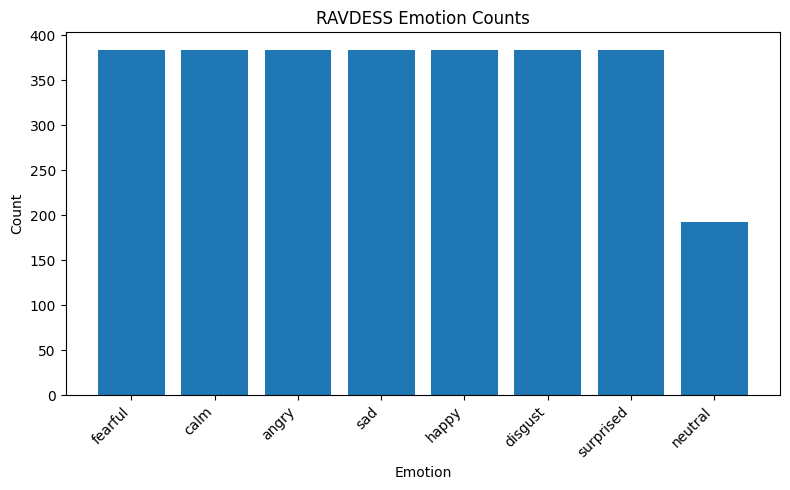

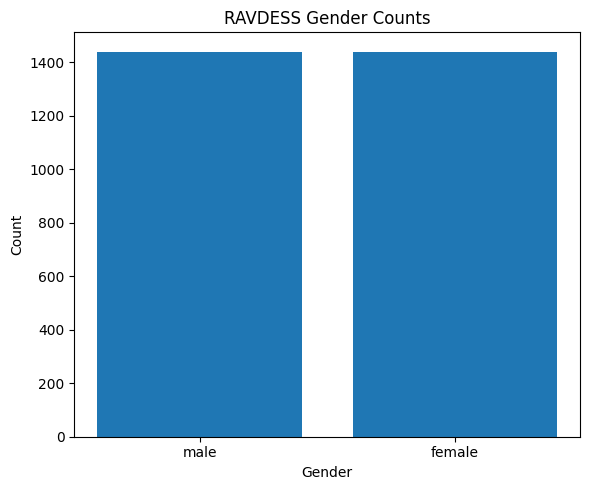

FER2013 metadata shape: (28709, 2)
                                          filepath emotion_label
0  ./data/fer2013/train/fear/Training_84244523.jpg          fear
1  ./data/fer2013/train/fear/Training_48011153.jpg          fear
2  ./data/fer2013/train/fear/Training_74071103.jpg          fear
3  ./data/fer2013/train/fear/Training_49507434.jpg          fear
4  ./data/fer2013/train/fear/Training_14592497.jpg          fear


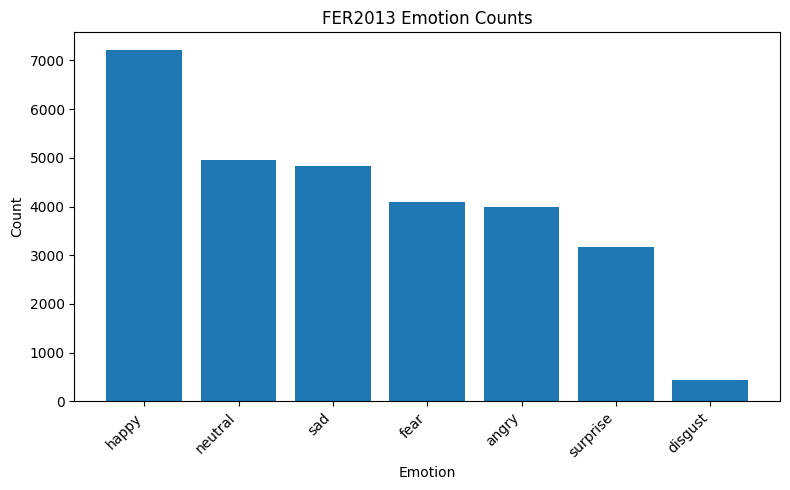

audio: 03-01-03-02-01-01-18.wav
emotion: happy
gender: female
actor_id: 18
statement: "Kids are talking by the door."

image: Training_97688399.jpg
emotion: sad


In [121]:
# allowed imports

RAVDESS_ROOT_DIR = "./data/ravdess"       # should directly contain Actor_01 ... Actor_24
FER2013_TRAIN_DIR = "./data/fer2013/train"  # should directly contain one subfolder per emotion

# -------------------------------------------------------------------------
# Part A: RAVDESS audio metadata
# -------------------------------------------------------------------------

VOCAL_CHANNEL_MAP = {1: "speech", 2: "song"}

EMOTION_MAP = {
    1: "neutral",
    2: "calm",
    3: "happy",
    4: "sad",
    5: "angry",
    6: "fearful",
    7: "disgust",
    8: "surprised",
}

INTENSITY_MAP = {1: "normal", 2: "strong"}

STATEMENT_TEXT_MAP = {
    1: "Kids are talking by the door.",
    2: "Dogs are sitting by the door.",
}

MODALITY_MAP = {1: "audio_video", 2: "video_only", 3: "audio_only"}


def parse_ravdess_filename(filename: str) -> dict:
    """
    Parse a RAVDESS audio filename into its metadata fields.
    Remember: gender is determined by the parity of actor_code
    (odd -> male, even -> female).
    """
    # YOUR CODE HERE
    name = os.path.basename(filename)
    name_no_ext = name.replace(".wav", "")
    parts = name_no_ext.split("-")

    modality_code = int(parts[0])
    vocal_channel_code = int(parts[1])
    emotion_code = int(parts[2])
    intensity_code = int(parts[3])
    statement_code = int(parts[4])
    repetition_code = int(parts[5])
    actor_code = int(parts[6])

    gender_label = "male" if actor_code % 2 == 1 else "female"

    return {
        "modality_code": modality_code,
        "modality_label": MODALITY_MAP.get(modality_code),
        "vocal_channel_code": vocal_channel_code,
        "vocal_channel_label": VOCAL_CHANNEL_MAP.get(vocal_channel_code),
        "emotion_code": emotion_code,
        "emotion_label": EMOTION_MAP.get(emotion_code),
        "intensity_code": intensity_code,
        "intensity_label": INTENSITY_MAP.get(intensity_code),
        "statement_code": statement_code,
        "statement_text": STATEMENT_TEXT_MAP.get(statement_code),
        "repetition_code": repetition_code,
        "actor_code": actor_code,
        "gender_label": gender_label,
    }
    raise NotImplementedError("parse_ravdess_filename is not implemented yet.")


def build_ravdess_metadata(ravdess_root_dir: str) -> pd.DataFrame:
    """
    Walk through Actor_01 ... Actor_24 folders under ravdess_root_dir,
    parse every .wav filename, and build a metadata DataFrame with a
    'filepath' column added to each row.
    """
    # YOUR CODE HERE
    records = []

    for root, dirs, files in os.walk(ravdess_root_dir):
        for file in files:
            if file.lower().endswith(".wav"):
                filepath = os.path.join(root, file)
                parsed = parse_ravdess_filename(file)
                parsed["filepath"] = filepath
                records.append(parsed)

    return pd.DataFrame(records)

    raise NotImplementedError("build_ravdess_metadata is not implemented yet.")


def load_audio(path_to_audio_file: str):
    """Load an audio file using librosa with the original sampling rate."""
    # YOUR CODE HERE
    audio, sr = librosa.load(path_to_audio_file, sr=None)
    return sr, audio
    raise NotImplementedError("load_audio is not implemented yet.")


def plot_ravdess_emotion_counts(metadata_df: pd.DataFrame):
    """Plot a bar chart of the number of RAVDESS audio files per emotion_label."""
    # YOUR CODE HERE
    counts = metadata_df["emotion_label"].value_counts()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(counts.index, counts.values)
    ax.set_title("RAVDESS Emotion Counts")
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    return fig


    raise NotImplementedError("plot_ravdess_emotion_counts is not implemented yet.")


def plot_ravdess_gender_counts(metadata_df: pd.DataFrame):
    """Plot a bar chart of the number of RAVDESS audio files per gender_label."""
    # YOUR CODE HERE
    counts = metadata_df["gender_label"].value_counts()

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.bar(counts.index, counts.values)
    ax.set_title("RAVDESS Gender Counts")
    ax.set_xlabel("Gender")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()
    return fig


    raise NotImplementedError("plot_ravdess_gender_counts is not implemented yet.")


ravdess_metadata = build_ravdess_metadata(RAVDESS_ROOT_DIR)
print("RAVDESS metadata shape:", ravdess_metadata.shape)
print(ravdess_metadata.head())

plot_ravdess_emotion_counts(ravdess_metadata)
plot_ravdess_gender_counts(ravdess_metadata)

# -------------------------------------------------------------------------
# Part B: FER2013 image metadata
# -------------------------------------------------------------------------

def build_fer2013_metadata(fer2013_train_dir: str) -> pd.DataFrame:
    """
    Walk through every emotion subfolder under fer2013_train_dir and build
    a metadata DataFrame with columns 'filepath' and 'emotion_label'
    (emotion_label = subfolder name).
    """
    # YOUR CODE HERE
    records = []

    for root, dirs, files in os.walk(fer2013_train_dir):
        for file in files:
            if file.lower().endswith(".jpg"):
                filepath = os.path.join(root, file)
                emotion_label = os.path.basename(root)
                records.append({"filepath": filepath, "emotion_label": emotion_label})

    return pd.DataFrame(records, columns=["filepath", "emotion_label"])

    raise NotImplementedError("build_fer2013_metadata is not implemented yet.")


def load_image(path_to_image_file: str) -> np.ndarray:
    """Load an image file using OpenCV and return it as a NumPy array."""
    # YOUR CODE HERE
    image = cv2.imread(path_to_image_file, cv2.IMREAD_GRAYSCALE)
    return np.asarray(image)

    raise NotImplementedError("load_image is not implemented yet.")


def plot_fer2013_emotion_counts(metadata_df: pd.DataFrame):
    """Plot a bar chart of the number of FER2013 images per emotion_label."""
    # YOUR CODE HERE
    counts = metadata_df["emotion_label"].value_counts()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(counts.index, counts.values)
    ax.set_title("FER2013 Emotion Counts")
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    return fig
    raise NotImplementedError("plot_fer2013_emotion_counts is not implemented yet.")


fer2013_metadata = build_fer2013_metadata(FER2013_TRAIN_DIR)
print("FER2013 metadata shape:", fer2013_metadata.shape)
print(fer2013_metadata.head())

plot_fer2013_emotion_counts(fer2013_metadata)

# -------------------------------------------------------------------------
# Part C: Sanity check - print details
# -------------------------------------------------------------------------

sample_audio_row = ravdess_metadata.sample(1, random_state=42).iloc[0]
print("audio:", os.path.basename(sample_audio_row["filepath"]))
print("emotion:", sample_audio_row["emotion_label"])
print("gender:", sample_audio_row["gender_label"])
print("actor_id:", sample_audio_row["actor_code"])
print(f'statement: "{sample_audio_row["statement_text"]}"')

print()

sample_image_row = fer2013_metadata.sample(1, random_state=42).iloc[0]
print("image:", os.path.basename(sample_image_row["filepath"]))
print("emotion:", sample_image_row["emotion_label"])


# `q2`: Data Augmentation and Preprocessing for FER2013 (Images) and RAVDESS (Audio)

In this question, you will implement **data handling operations** for:

- FER2013 face images (emotion-labeled, grayscale).
- RAVDESS speech audio clips (emotion-labeled, .wav files).

The goal is to:
1. Perform **basic preprocessing** (resizing, normalization).
2. Implement **data augmentation** (geometric and noise-based transformations).
3. Prepare augmented examples for visualization and later feature extraction.

You will write functions that operate on **single samples** (one image or one audio clip),
and later we will apply them to many samples in a separate cell.

We provide the paths and metadata from `q1`:
- `FER2013_TRAIN_DIR` points to the FER2013 train folder.
- `RAVDESS_ROOT_DIR` points to the RAVDESS root folder.
- `fer2013_metadata` is a DataFrame with FER2013 image paths and emotion labels.
- `ravdess_metadata` is a DataFrame with RAVDESS audio paths and parsed labels.

---

## Part A: FER2013 Image Preprocessing and Augmentation

FER2013 images in the train folder are grayscale faces, but we may treat them as
either single-channel or 3-channel (by stacking) for visualization.

You must implement:

1. `resize_image(image, size=(64, 64))`
   - Input: `image` as a NumPy array of shape `(H, W)` or `(H, W, C)`.
   - Output: resized image of shape `(size[1], size[0])` (grayscale)
     or `(size[1], size[0], C)` (color), using OpenCV.

2. `normalize_image(image)`
   - Input: image array (grayscale or color).
   - Output: float32 array of the same shape with pixel values **normalized to [0, 1]**
     using min–max normalization per image.

3. `augment_image(image, rotate_degrees=15, horizontal_flip=True, add_noise=True)`
   - Input: original image array.
   - Process (in this order):
     1. Rotate the image by `rotate_degrees` around its center (using OpenCV).
     2. If `horizontal_flip=True`, flip the image left-right.
     3. If `add_noise=True`, add zero-mean Gaussian noise with a small standard deviation
        (e.g., `0.05` in the normalized [0, 1] scale) and clip back to [0, 1].
   - Output: augmented image as float32 in [0, 1].

---

## Part B: RAVDESS Audio Preprocessing and Augmentation

RAVDESS audio clips are .wav speech files. You must implement:

4. `normalize_audio(audio)`
   - Input: 1D NumPy array representing the audio waveform.
   - Output: audio scaled so that its maximum absolute value is **1.0**
     (peak normalization). If the input is all zeros, return it unchanged.

5. `augment_audio_time_stretch(audio, rate)`
   - Input: audio array and a stretch factor `rate` (e.g., 0.9 for slower, 1.1 for faster).
   - Output: time-stretched audio using `librosa.effects.time_stretch`.

6. `augment_audio_pitch_shift(audio, sr, n_steps)`
   - Input: audio array, sampling rate `sr`, and pitch shift in semitones `n_steps`
     (positive for higher pitch, negative for lower pitch).
   - Output: pitch-shifted audio using `librosa.effects.pitch_shift`.

7. `augment_audio_add_noise(audio, noise_std)`
   - Input: audio array and noise standard deviation `noise_std` (e.g., 0.01).
   - Output: audio with zero-mean Gaussian noise added, same length as input.

---

## Part C: Sample-level helper functions

Finally, you will implement:

8. `process_fer2013_sample(image_path)`
   - Input: path to a single FER2013 `.jpg` image.
   - Process:
     1. Load the image with `cv2.imread` (grayscale).
     2. Resize, normalize, and augment using the functions above.
   - Output: a dictionary with keys:
     - `"original"`: original grayscale image.
     - `"resized"`: resized grayscale image.
     - `"normalized"`: normalized resized image.
     - `"augmented"`: augmented normalized image.

9. `process_ravdess_sample(audio_path)`
   - Input: path to a single RAVDESS `.wav` audio file.
   - Process:
     1. Load audio using `librosa.load(sr=None, mono=True)` to keep original `sr`.
     2. Normalize and create three augmented versions:
        - time-stretched (e.g., rate=0.9),
        - pitch-shifted (e.g., n_steps=+2),
        - noise-added (e.g., noise_std=0.01).
   - Output: a dictionary with keys:
     - `"sr"`: sampling rate.
     - `"original"`: original audio waveform.
     - `"normalized"`: normalized audio.
     - `"time_stretched"`: augmented audio.
     - `"pitch_shifted"`: augmented audio.
     - `"noisy"`: augmented audio.

---

## Grading [Total: 2 points]

| Question | Function | Marks |
|---|---|---:|
| `1` | `resize_image(image, size=(64, 64))` | 0.20 |
| `2` | `normalize_image(image)` | 0.25 |
| `3` | `augment_image(image, rotate_degrees=15, horizontal_flip=True, add_noise=True)` | 0.35 |
| `4` | `normalize_audio(audio)` | 0.20 |
| `5` | `augment_audio_time_stretch(audio, rate)` | 0.25 |
| `6` | `augment_audio_pitch_shift(audio, sr, n_steps)` | 0.25 |
| `7` | `augment_audio_add_noise(audio, noise_std)` | 0.10 |
| `8` | `process_fer2013_sample(image_path)` | 0.20 |
| `9` | `process_ravdess_sample(audio_path)` | 0.20 |
|  | **Total** | **2.00** |

No partial points will be awarded for any individual function. Each function
must run without errors on hidden test cases to receive its assigned marks.

You are provided with the following template. **Populate only the sections marked as `# YOUR CODE HERE`. Do not modify other parts of the template.**

In [122]:
# q2: Data augmentation and preprocessing for FER2013 (images) and RAVDESS (audio)

# Assumes the following are defined in q1:
# - FER2013_TRAIN_DIR
# - RAVDESS_ROOT_DIR
# - fer2013_metadata
# - ravdess_metadata

# -------------------------------------------------------------------------
# Part A: FER2013 image preprocessing and augmentation
# -------------------------------------------------------------------------

def resize_image(image, size=(64, 64)):
    """
    Resize an input image to the specified dimensions.

    Parameters
    ----------
    image : numpy.ndarray
        Input image of shape (H, W) for grayscale or (H, W, C) for color.
    size : tuple of int, optional
        Desired output size as (width, height). Defaults to (64, 64).

    Returns
    -------
    numpy.ndarray
        Resized image with shape (size[1], size[0]) for grayscale or
        (size[1], size[0], C) for color, preserving the number of channels.
    """
    # YOUR CODE HERE
    return cv2.resize(image, size, interpolation=cv2.INTER_LINEAR)
    raise NotImplementedError("resize_image is not implemented yet.")


def normalize_image(image):
    """
    Normalize an image to the [0, 1] range using min–max normalization.

    Parameters
    ----------
    image : numpy.ndarray
        Input image (grayscale or color) with arbitrary value range.

    Returns
    -------
    numpy.ndarray
        Float32 image of the same shape, with values in [0, 1].
        If the image has constant value, return zeros of the same shape.
    """
    # YOUR CODE HERE
    image = np.asarray(image, dtype=np.float32)
    min_val = image.min()
    max_val = image.max()

    if max_val == min_val:
        return np.zeros_like(image, dtype=np.float32)

    normalized = (image - min_val) / (max_val - min_val)
    return normalized.astype(np.float32)
    raise NotImplementedError("normalize_image is not implemented yet.")


def augment_image(image, rotate_degrees=15, horizontal_flip=True, add_noise=True):
    """
    Apply deterministic augmentations to an image:
    1. Rotate by rotate_degrees.
    2. Optionally horizontal flip.
    3. Optionally add zero-mean Gaussian noise in normalized [0, 1] scale.

    Parameters
    ----------
    image : numpy.ndarray
        Input image (assumed already normalized to [0, 1]).
    rotate_degrees : float
        Rotation angle in degrees (positive rotates counter-clockwise).
    horizontal_flip : bool
        Whether to horizontally flip the image after rotation.
    add_noise : bool
        Whether to add Gaussian noise.

    Returns
    -------
    numpy.ndarray
        Augmented image (float32) with values clipped to [0, 1].
    """
    # YOUR CODE HERE
    image = np.asarray(image, dtype=np.float32)
    h, w = image.shape[:2]

    center = (w / 2, h / 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, rotate_degrees, 1.0)
    rotated = cv2.warpAffine(image, rotation_matrix, (w, h))

    if horizontal_flip:
        rotated = cv2.flip(rotated, 1)

    if add_noise:
        noise = np.random.normal(loc=0.0, scale=0.05, size=rotated.shape).astype(np.float32)
        rotated = rotated + noise

    rotated = np.clip(rotated, 0.0, 1.0)
    return rotated.astype(np.float32)
    raise NotImplementedError("augment_image is not implemented yet.")


# -------------------------------------------------------------------------
# Part B: RAVDESS audio preprocessing and augmentation
# -------------------------------------------------------------------------

def normalize_audio(audio):
    """
    Peak-normalize an audio waveform so that max absolute value is 1.0.

    Parameters
    ----------
    audio : numpy.ndarray
        1D array containing audio samples.

    Returns
    -------
    numpy.ndarray
        Normalized audio of the same shape. If max abs value is 0, returns
        the input unchanged.
    """
    # YOUR CODE HERE
    audio = np.asarray(audio, dtype=np.float64)
    max_abs = np.max(np.abs(audio))

    if max_abs == 0:
        return audio

    return audio / max_abs
    raise NotImplementedError("normalize_audio is not implemented yet.")


def augment_audio_time_stretch(audio, rate):
    """
    Apply time-stretching to an audio signal.

    Parameters
    ----------
    audio : numpy.ndarray
        1D array of audio samples.
    rate : float
        Stretch factor (e.g., 0.9 for slower, 1.1 for faster).

    Returns
    -------
    numpy.ndarray
        Time-stretched audio signal.
    """
    # YOUR CODE HERE
    audio = np.asarray(audio, dtype=np.float64)
    return librosa.effects.time_stretch(y=audio, rate=rate)
    raise NotImplementedError("augment_audio_time_stretch is not implemented yet.")


def augment_audio_pitch_shift(audio, sr, n_steps):
    """
    Apply pitch-shifting to an audio signal.

    Parameters
    ----------
    audio : numpy.ndarray
        1D array of audio samples.
    sr : int
        Sampling rate of the audio signal.
    n_steps : float
        Pitch shift in semitones (positive for higher pitch, negative for lower).

    Returns
    -------
    numpy.ndarray
        Pitch-shifted audio signal.
    """
    # YOUR CODE HERE
    audio = np.asarray(audio, dtype=np.float64)
    return librosa.effects.pitch_shift(y=audio, sr=sr, n_steps=n_steps)
    raise NotImplementedError("augment_audio_pitch_shift is not implemented yet.")


def augment_audio_add_noise(audio, noise_std):
    """
    Add zero-mean Gaussian noise to an audio signal.

    Parameters
    ----------
    audio : numpy.ndarray
        1D array of audio samples.
    noise_std : float
        Standard deviation of the Gaussian noise.

    Returns
    -------
    numpy.ndarray
        Noisy audio signal of the same shape.
    """
    # YOUR CODE HERE
    audio = np.asarray(audio, dtype=np.float64)
    noise = np.random.normal(loc=0.0, scale=noise_std, size=audio.shape)
    return audio + noise
    raise NotImplementedError("augment_audio_add_noise is not implemented yet.")


# -------------------------------------------------------------------------
# Part C: Sample-level helper functions
# -------------------------------------------------------------------------

def process_fer2013_sample(image_path):
    """
    Load and process a single FER2013 image.

    Steps:
    1. Load the image as grayscale.
    2. Resize to a fixed size.
    3. Normalize to [0, 1].
    4. Apply augmentation.

    Parameters
    ----------
    image_path : str
        Path to a FER2013 .jpg image.

    Returns
    -------
    dict
        Dictionary with keys:
        - 'original': original grayscale image.
        - 'resized': resized image.
        - 'normalized': normalized resized image.
        - 'augmented': augmented normalized image.
    """
    # YOUR CODE HERE
    original = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    resized = resize_image(original)
    normalized = normalize_image(resized)
    augmented = augment_image(normalized)

    return {
        "original": original,
        "resized": resized,
        "normalized": normalized,
        "augmented": augmented,
    }
    raise NotImplementedError("process_fer2013_sample is not implemented yet.")


def process_ravdess_sample(audio_path):
    """
    Load and process a single RAVDESS audio file.

    Steps:
    1. Load audio with librosa.load(sr=None, mono=True).
    2. Normalize audio.
    3. Create time-stretched, pitch-shifted, and noisy versions.

    Parameters
    ----------
    audio_path : str
        Path to a RAVDESS .wav audio file.

    Returns
    -------
    dict
        Dictionary with keys:
        - 'sr': sampling rate.
        - 'original': original audio waveform.
        - 'normalized': normalized audio waveform.
        - 'time_stretched': time-stretched audio.
        - 'pitch_shifted': pitch-shifted audio.
        - 'noisy': noisy audio.
    """
    # YOUR CODE HERE
    audio, sr = librosa.load(audio_path, sr=None, mono=True)

    normalized = normalize_audio(audio)
    time_stretched = augment_audio_time_stretch(normalized, rate=0.9)
    pitch_shifted = augment_audio_pitch_shift(normalized, sr, n_steps=2)
    noisy = augment_audio_add_noise(normalized, noise_std=0.01)

    return {
        "sr": sr,
        "original": audio,
        "normalized": normalized,
        "time_stretched": time_stretched,
        "pitch_shifted": pitch_shifted,
        "noisy": noisy,
    }
    raise NotImplementedError("process_ravdess_sample is not implemented yet.")

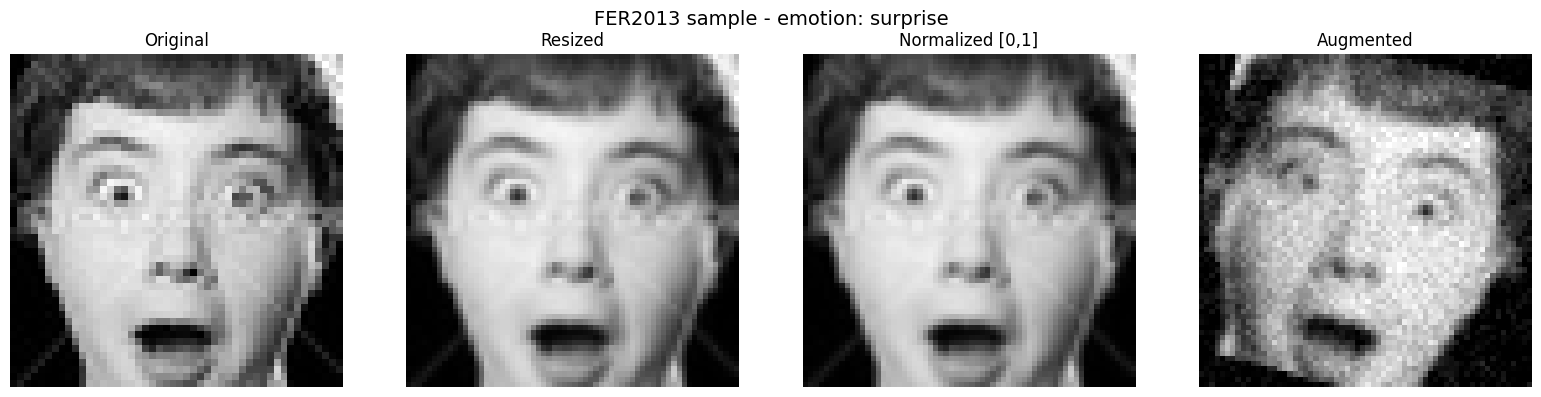

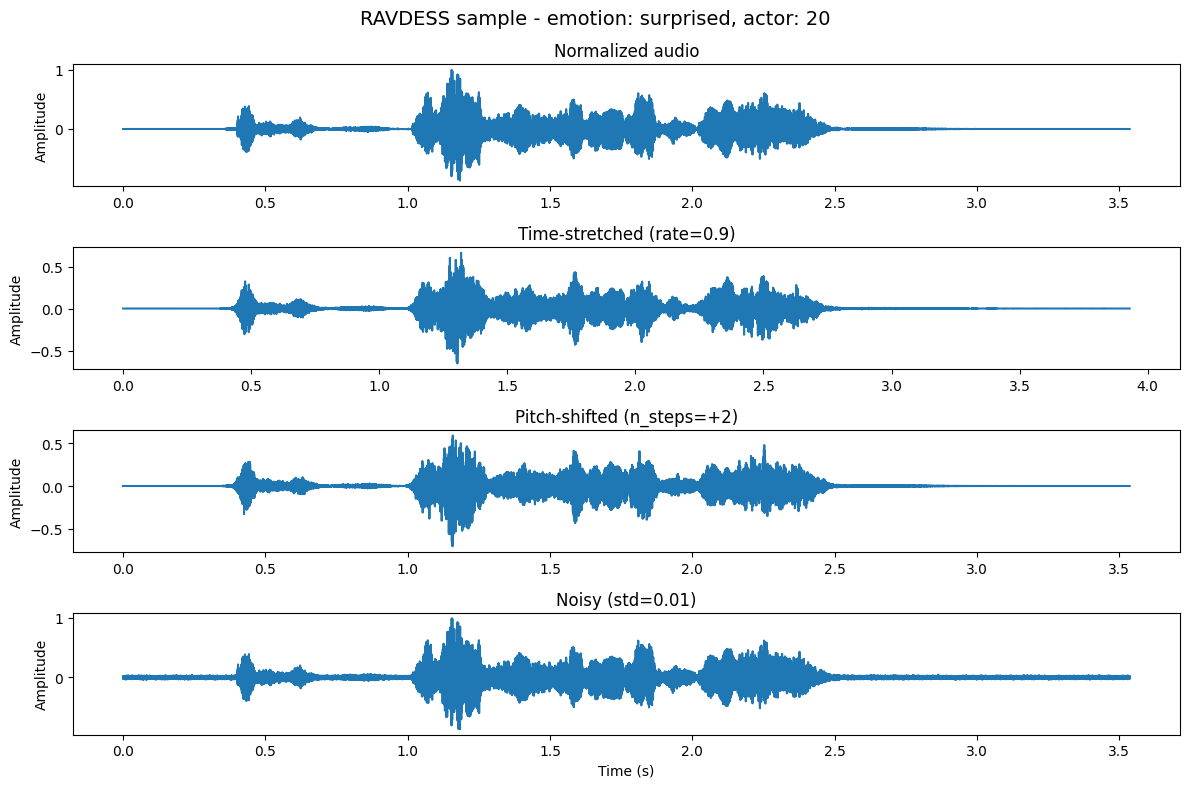

FER2013 sample:
 image: Training_49536666.jpg
 emotion: surprise

RAVDESS sample:
 audio: 03-01-08-02-02-01-20.wav
 emotion: surprised
 actor_id: 20


In [123]:
# You should NOT change this code cell.
# Demo: use Q2 functions on a few FER2013 and RAVDESS samples.

# Sample one FER2013 image
fer_sample_row = fer2013_metadata.sample(1, random_state=123).iloc[0]
fer_image_path = fer_sample_row["filepath"]
fer_emotion = fer_sample_row["emotion_label"]

fer_outputs = process_fer2013_sample(fer_image_path)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(f"FER2013 sample - emotion: {fer_emotion}", fontsize=14)

axes[0].imshow(fer_outputs["original"], cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(fer_outputs["resized"], cmap="gray")
axes[1].set_title("Resized")
axes[1].axis("off")

axes[2].imshow(fer_outputs["normalized"], cmap="gray")
axes[2].set_title("Normalized [0,1]")
axes[2].axis("off")

axes[3].imshow(fer_outputs["augmented"], cmap="gray")
axes[3].set_title("Augmented")
axes[3].axis("off")

plt.tight_layout()
plt.show()

# Sample one RAVDESS audio
rav_sample_row = ravdess_metadata.sample(1, random_state=456).iloc[0]
rav_audio_path = rav_sample_row["filepath"]
rav_emotion = rav_sample_row["emotion_label"]
rav_actor = rav_sample_row["actor_code"]

rav_outputs = process_ravdess_sample(rav_audio_path)

sr = rav_outputs["sr"]
audio_norm = rav_outputs["normalized"]
audio_time = rav_outputs["time_stretched"]
audio_pitch = rav_outputs["pitch_shifted"]
audio_noisy = rav_outputs["noisy"]

time_norm = np.arange(len(audio_norm)) / sr
time_time = np.arange(len(audio_time)) / sr
time_pitch = np.arange(len(audio_pitch)) / sr
time_noisy = np.arange(len(audio_noisy)) / sr

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=False)
fig.suptitle(
    f"RAVDESS sample - emotion: {rav_emotion}, actor: {rav_actor}", fontsize=14
)

axes[0].plot(time_norm, audio_norm)
axes[0].set_title("Normalized audio")
axes[0].set_ylabel("Amplitude")

axes[1].plot(time_time, audio_time)
axes[1].set_title("Time-stretched (rate=0.9)")
axes[1].set_ylabel("Amplitude")

axes[2].plot(time_pitch, audio_pitch)
axes[2].set_title("Pitch-shifted (n_steps=+2)")
axes[2].set_ylabel("Amplitude")

axes[3].plot(time_noisy, audio_noisy)
axes[3].set_title("Noisy (std=0.01)")
axes[3].set_xlabel("Time (s)")
axes[3].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

# Print brief text summary
print("FER2013 sample:")
print(" image:", os.path.basename(fer_image_path))
print(" emotion:", fer_emotion)
print()
print("RAVDESS sample:")
print(" audio:", os.path.basename(rav_audio_path))
print(" emotion:", rav_emotion)
print(" actor_id:", rav_actor)

# `q3`: Feature Extraction for Images (FER2013) and Audio (RAVDESS)

This question has a **compulsory common part** and a **tiered advanced part**
(`q3_3xx` vs `q3_5xx`), scored on the same marks.

## Part A: Image Feature Extraction (Compulsory)

1. `get_histogram(image_array)` — 1D array length 256, pixel intensity histogram.
2. `get_image_lbp(img_array)` — tuple `(lbp_image, lbp_hist)`, LBP-encoded image + normalized histogram (length 256).
3. `get_sobel_edges(img_array)` — tuple `(sobel_x, sobel_y, magnitude)`, uint8 arrays shape (H, W).
4. `get_hog_features(img_array, win_size=(64, 64))` — 1D HOG feature vector.

## Part B: Audio Feature Extraction (Compulsory)

5. `get_zero_crossing_rate(audio, frame_length=2048, hop_length=512)` — 1D ZCR array.
6. `get_spectrogram(audio, n_fft=2048, hop_length=512)` — 2D linear spectrogram (dB).
7. `get_mel_spectrogram(audio, sr, n_fft=2048, hop_length=512, n_mels=128)` — 2D mel spectrogram.
8. `get_log_mel_spectrogram(mel_spec)` — 2D log-mel (dB).
9. `get_mfcc(audio, sr, n_mfcc=13)` — 2D MFCC array (n_mfcc, time_frames).

## Part C: Tiered Task

### `q3_3xx`  — Feature Aggregation
10. `aggregate_image_features(hist, lbp_hist)` — normalize both to sum-1, concatenate.
11. `aggregate_audio_features(mfcc)` — concat mean+std of MFCC per coefficient across time (length 2*n_mfcc).

### `q3_5xx`  — From-Scratch LBP + Discriminability
12. `get_image_lbp_from_scratch(img_array)` — same contract, NO library LBP, vectorized (no per-pixel loop).
13. `feature_discriminability(features_by_class)` — dict emotion→2D array; Fisher-like score = between-class variance / within-class variance per feature dim.

## Grading [Total: 3 points]

### Part A: Image Feature Extraction — Compulsory [1 point]

| Question | Function | Marks |
|---|---|---:|
| `1` | `get_histogram(image_array)` | 0.15 |
| `2` | `get_image_lbp(img_array)` | 0.35 |
| `3` | `get_sobel_edges(img_array)` | 0.20 |
| `4` | `get_hog_features(img_array, win_size=(64, 64))` | 0.30 |
|  | **Part A Total** | **1.00** |

### Part B: Audio Feature Extraction — Compulsory [1 point]

| Question | Function | Marks |
|---|---|---:|
| `5` | `get_zero_crossing_rate(audio, frame_length=2048, hop_length=512)` | 0.15 |
| `6` | `get_spectrogram(audio, n_fft=2048, hop_length=512)` | 0.20 |
| `7` | `get_mel_spectrogram(audio, sr, n_fft=2048, hop_length=512, n_mels=128)` | 0.20 |
| `8` | `get_log_mel_spectrogram(mel_spec)` | 0.15 |
| `9` | `get_mfcc(audio, sr, n_mfcc=13)` | 0.30 |
|  | **Part B Total** | **1.00** |

### Part C: 3xx — Feature Aggregation [1 point]

| Question | Function | Marks |
|---|---|---:|
| `10` | `aggregate_image_features(hist, lbp_hist)` | 0.40 |
| `11` | `aggregate_audio_features(mfcc)` | 0.60 |
|  | **Part C Total** | **1.00** |

### Part C: 5xx — Advanced Feature Analysis [1 point]

| Question | Function / Task | Marks |
|---|---|---:|
| `12` | `get_image_lbp_from_scratch(img_array)` | 0.60 |
| `13` | `feature_discriminability(features_by_class)` | 0.40 |
|  | **Part C Total** | **1.00** |


No partial points will be awarded for any individual programming function. Each
function must run without errors on hidden test cases to receive its assigned
marks.

In [124]:
def get_histogram(image_array):
    """1D histogram (length 256) of a grayscale image's pixel intensities."""
    # YOUR CODE HERE
    image_array = np.asarray(image_array).astype(np.uint8)
    hist, _ = np.histogram(image_array.flatten(), bins=256, range=(0, 256))
    return hist
    raise NotImplementedError("get_histogram is not implemented yet.")

def get_image_lbp(img_array):
    """Return (lbp_image, lbp_hist): (H,W) uint8 LBP codes, length-256 normalized histogram."""
    # YOUR CODE HERE
    img_array = np.asarray(img_array, dtype=np.float64)
    h, w = img_array.shape

    padded = np.pad(img_array, pad_width=1, mode="edge")

    offsets = [(-1, -1), (-1, 0), (-1, 1), (0, 1), (1, 1), (1, 0), (1, -1), (0, -1)]

    lbp_image = np.zeros((h, w), dtype=np.uint8)
    center = padded[1:h+1, 1:w+1]

    for i, (dy, dx) in enumerate(offsets):
        neighbor = padded[1+dy:1+dy+h, 1+dx:1+dx+w]
        bit = (neighbor >= center).astype(np.uint8)
        lbp_image += (bit << i).astype(np.uint8)

    lbp_hist, _ = np.histogram(lbp_image.flatten(), bins=256, range=(0, 256))
    lbp_hist = lbp_hist.astype(np.float64)
    total = lbp_hist.sum()
    if total > 0:
        lbp_hist = lbp_hist / total

    return lbp_image, lbp_hist
    raise NotImplementedError("get_image_lbp is not implemented yet.")

def get_sobel_edges(img_array):
    """Return (sobel_x, sobel_y, magnitude), each uint8 arrays of shape (H, W)."""
    # YOUR CODE HERE
    img_array = np.asarray(img_array, dtype=np.float64)

    sobel_x = cv2.Sobel(img_array, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img_array, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(sobel_x ** 2 + sobel_y ** 2)

    def to_uint8(arr):
        arr_abs = np.abs(arr)
        max_val = arr_abs.max()
        if max_val == 0:
            return np.zeros_like(arr_abs, dtype=np.uint8)
        scaled = (arr_abs / max_val) * 255.0
        return scaled.astype(np.uint8)

    return to_uint8(sobel_x), to_uint8(sobel_y), to_uint8(magnitude)
    raise NotImplementedError("get_sobel_edges is not implemented yet.")

def get_hog_features(img_array, win_size=(64, 64)):
    """Return a 1D HOG feature vector for the (resized) grayscale image."""
    # YOUR CODE HERE
    img_array = np.asarray(img_array)
    if img_array.shape[:2] != (win_size[1], win_size[0]):
        img_resized = cv2.resize(img_array, win_size)
    else:
        img_resized = img_array

    img_resized = img_resized.astype(np.uint8)

    hog = cv2.HOGDescriptor(
        _winSize=win_size,
        _blockSize=(16, 16),
        _blockStride=(8, 8),
        _cellSize=(8, 8),
        _nbins=9
    )

    features = hog.compute(img_resized)
    features = features.flatten().astype(np.float64)
    return features
    raise NotImplementedError("get_hog_features is not implemented yet.")

def get_zero_crossing_rate(audio, frame_length=2048, hop_length=512):
    """1D array of ZCR values, one per frame."""
    # YOUR CODE HERE
    audio = np.asarray(audio, dtype=np.float64)
    zcr = librosa.feature.zero_crossing_rate(
        y=audio, frame_length=frame_length, hop_length=hop_length
    )
    return zcr.flatten()
    raise NotImplementedError("get_zero_crossing_rate is not implemented yet.")

def get_spectrogram(audio, n_fft=2048, hop_length=512):
    """2D linear spectrogram (freq_bins, time_frames) in dB."""
    # YOUR CODE HERE
    audio = np.asarray(audio, dtype=np.float64)
    stft = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length)
    magnitude = np.abs(stft)
    spectrogram_db = librosa.amplitude_to_db(magnitude, ref=np.max)
    return spectrogram_db
    raise NotImplementedError("get_spectrogram is not implemented yet.")

def get_mel_spectrogram(audio, sr, n_fft=2048, hop_length=512, n_mels=128):
    """2D mel spectrogram (n_mels, time_frames)."""
    # YOUR CODE HERE
    audio = np.asarray(audio, dtype=np.float64)
    mel_spec = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
    )
    return mel_spec
    raise NotImplementedError("get_mel_spectrogram is not implemented yet.")

def get_log_mel_spectrogram(mel_spec):
    """2D log-magnitude (dB) version of the input mel spectrogram."""
    # YOUR CODE HERE
    mel_spec = np.asarray(mel_spec, dtype=np.float64)
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
    return log_mel_spec
    raise NotImplementedError("get_log_mel_spectrogram is not implemented yet.")

def get_mfcc(audio, sr, n_mfcc=13):
    """2D MFCC array (n_mfcc, time_frames)."""
    # YOUR CODE HERE
    audio = np.asarray(audio, dtype=np.float64)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    return mfcc
    raise NotImplementedError("get_mfcc is not implemented yet.")

# q3_3xx [1 point]
def aggregate_image_features(hist, lbp_hist):
    """Concatenate normalized (sum-to-1) histogram and LBP histogram."""
    # YOUR CODE HERE
    hist = np.asarray(hist, dtype=np.float64)
    lbp_hist = np.asarray(lbp_hist, dtype=np.float64)

    hist_sum = hist.sum()
    hist_norm = hist / hist_sum if hist_sum > 0 else hist

    lbp_sum = lbp_hist.sum()
    lbp_norm = lbp_hist / lbp_sum if lbp_sum > 0 else lbp_hist

    return np.concatenate([hist_norm, lbp_norm])
    raise NotImplementedError("aggregate_image_features is not implemented yet.")

def aggregate_audio_features(mfcc):
    """Concatenate per-coefficient mean and std of MFCC across time -> length 2*n_mfcc."""
    # YOUR CODE HERE
    mfcc = np.asarray(mfcc, dtype=np.float64)
    mean_per_coeff = np.mean(mfcc, axis=1)
    std_per_coeff = np.std(mfcc, axis=1)
    return np.concatenate([mean_per_coeff, std_per_coeff])
    raise NotImplementedError("aggregate_audio_features is not implemented yet.")

# q3_5xx [1 point]
def get_image_lbp_from_scratch(img_array):
    """Same contract as get_image_lbp, manual NumPy only, vectorized."""
    # YOUR CODE HERE
    img_array = np.asarray(img_array, dtype=np.float64)
    h, w = img_array.shape

    padded = np.pad(img_array, pad_width=1, mode="edge")
    center = padded[1:h+1, 1:w+1]

    offsets = [(-1, -1), (-1, 0), (-1, 1), (0, 1), (1, 1), (1, 0), (1, -1), (0, -1)]

    lbp_image = np.zeros((h, w), dtype=np.uint8)

    for i, (dy, dx) in enumerate(offsets):
        neighbor = padded[1+dy:1+dy+h, 1+dx:1+dx+w]
        bit = (neighbor >= center).astype(np.uint8)
        lbp_image += (bit << i).astype(np.uint8)

    lbp_hist, _ = np.histogram(lbp_image.flatten(), bins=256, range=(0, 256))
    lbp_hist = lbp_hist.astype(np.float64)
    total = lbp_hist.sum()
    if total > 0:
        lbp_hist = lbp_hist / total

    return lbp_image, lbp_hist
    raise NotImplementedError("get_image_lbp_from_scratch is not implemented yet.")

def feature_discriminability(features_by_class):
    """dict[label -> (n_samples, n_features)] -> 1D array of Fisher-like scores."""
    # YOUR CODE HERE
    class_labels = list(features_by_class.keys())
    all_features = np.concatenate([features_by_class[c] for c in class_labels], axis=0)
    overall_mean = np.mean(all_features, axis=0)

    n_features = all_features.shape[1]
    between_class_var = np.zeros(n_features, dtype=np.float64)
    within_class_var = np.zeros(n_features, dtype=np.float64)

    for c in class_labels:
        class_features = features_by_class[c]
        n_c = class_features.shape[0]
        class_mean = np.mean(class_features, axis=0)

        between_class_var += n_c * (class_mean - overall_mean) ** 2
        within_class_var += np.sum((class_features - class_mean) ** 2, axis=0)

    within_class_var = np.where(within_class_var == 0, 1e-10, within_class_var)

    scores = between_class_var / within_class_var
    return scores

    raise NotImplementedError("feature_discriminability is not implemented yet.")



========== FER2013 IMAGE FEATURE EXTRACTION ==========
image file: Training_55440744.jpg
emotion: angry
original/resized image shape: (64, 64)
histogram shape: (256,)
histogram sum: 4096
LBP image shape: (64, 64)
LBP histogram shape: (256,)
LBP histogram sum: 1.0
Sobel magnitude shape: (64, 64)
HOG feature vector shape: (1764,)
aggregated image feature vector shape: (512,)


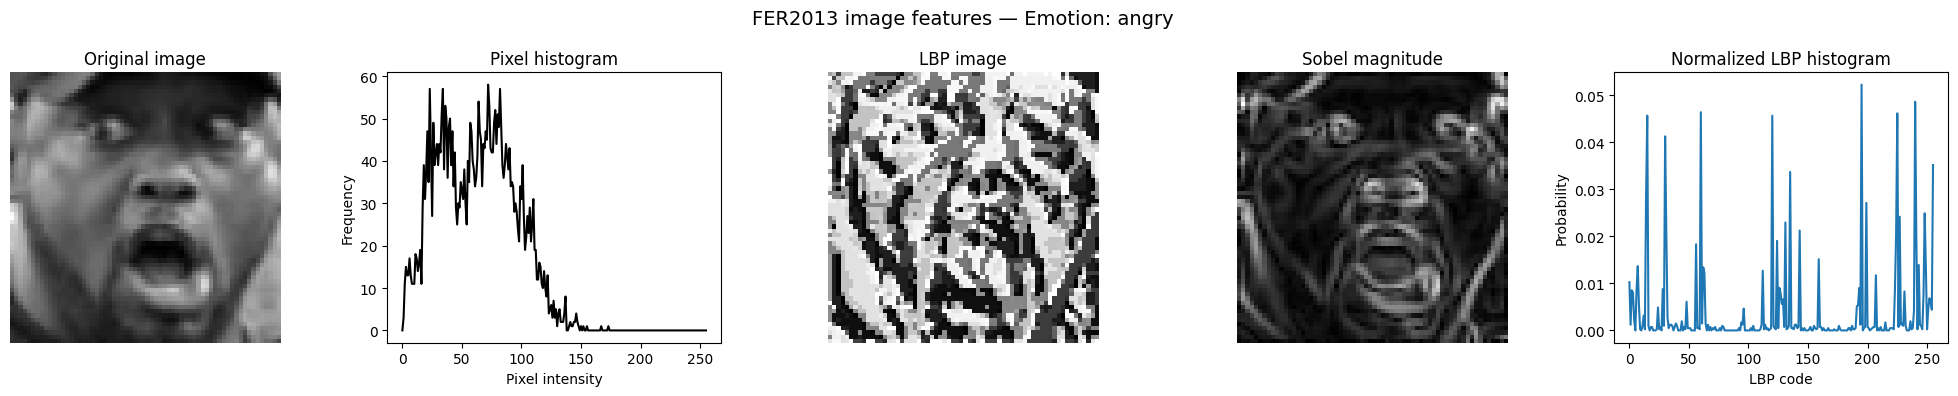


========== RAVDESS AUDIO FEATURE EXTRACTION ==========
audio file: 03-01-04-01-01-01-12.wav
emotion: sad
actor_id: 12
sampling rate: 48000
audio samples: 176176
duration (seconds): 3.67
ZCR shape: (345,)
spectrogram shape: (1025, 345)
mel spectrogram shape: (128, 345)
log-mel spectrogram shape: (128, 345)
MFCC shape: (13, 345)
aggregated audio feature vector shape: (26,)


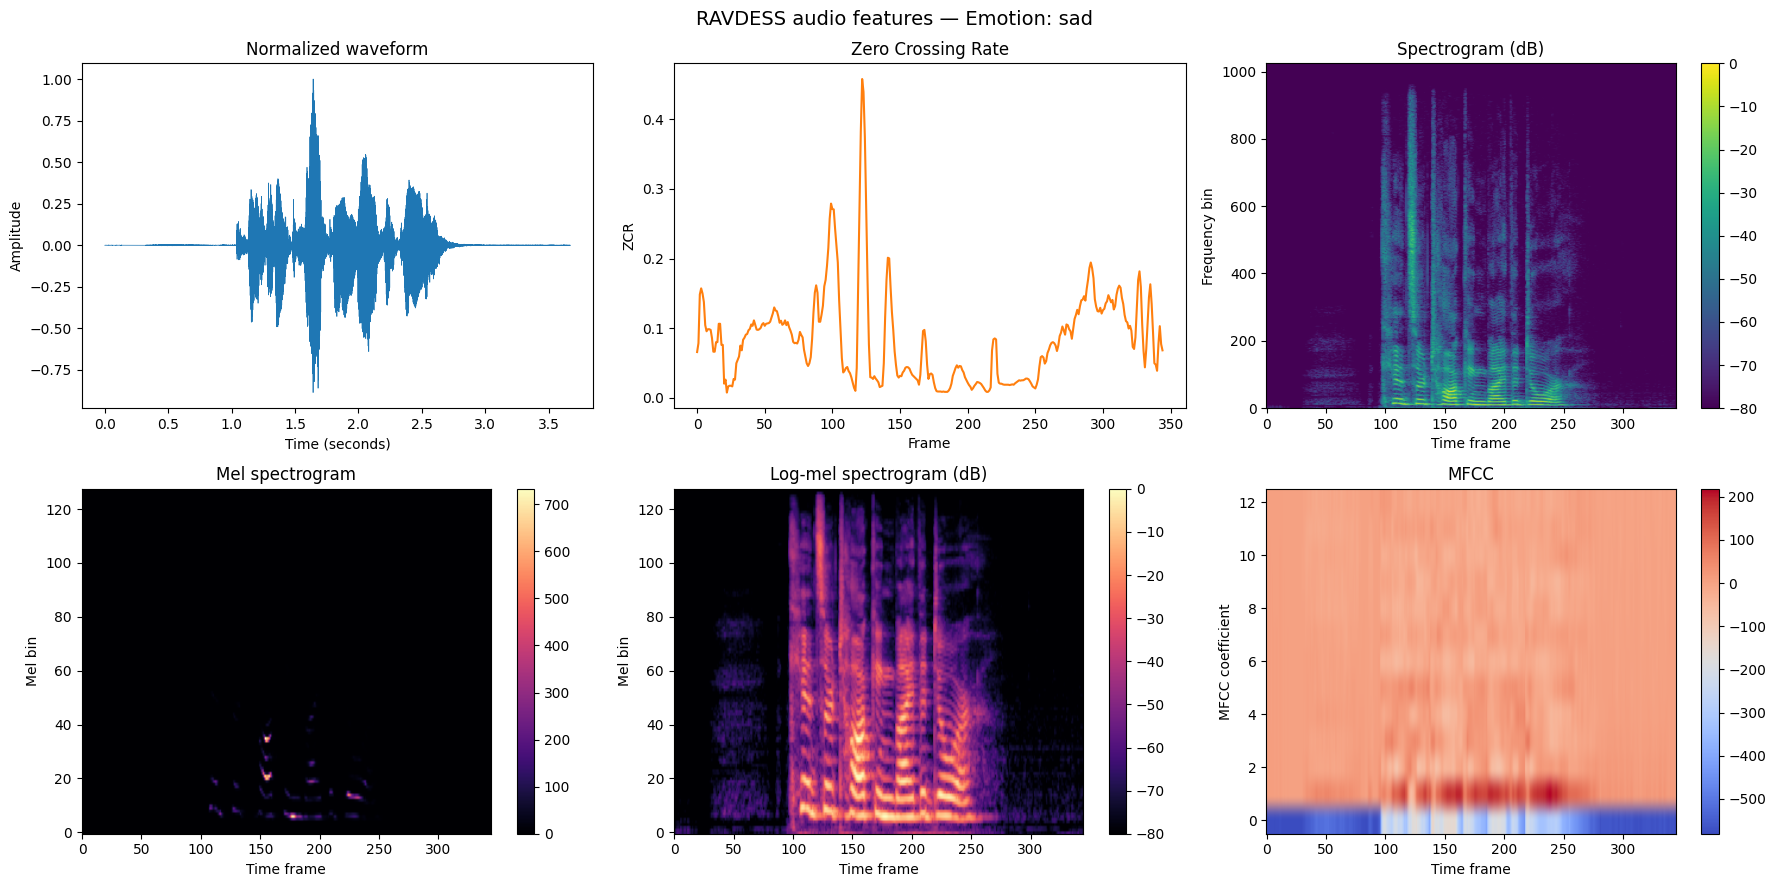


========== 5xx Q3 CHECK ==========
From-scratch LBP shape: (64, 64)
From-scratch LBP histogram shape: (256,)
LBP images equal: True


In [125]:
# You should NOT change this code cell.
# Q3: Feature extraction demo and sanity checks.

# -------------------------------------------------------------------------
# One FER2013 image
# -------------------------------------------------------------------------
image_row = fer2013_metadata.sample(1, random_state=10).iloc[0]

image_path = image_row["filepath"]
image_emotion = image_row["emotion_label"]

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if image is None:
    raise IOError(f"Could not read image: {image_path}")

image = cv2.resize(image, (64, 64))

hist = get_histogram(image)
lbp_image, lbp_hist = get_image_lbp(image)
sobel_x, sobel_y, sobel_magnitude = get_sobel_edges(image)
hog_features = get_hog_features(image)
image_features = aggregate_image_features(hist, lbp_hist)

print("========== FER2013 IMAGE FEATURE EXTRACTION ==========")
print("image file:", os.path.basename(image_path))
print("emotion:", image_emotion)
print("original/resized image shape:", image.shape)
print("histogram shape:", hist.shape)
print("histogram sum:", hist.sum())
print("LBP image shape:", lbp_image.shape)
print("LBP histogram shape:", lbp_hist.shape)
print("LBP histogram sum:", lbp_hist.sum())
print("Sobel magnitude shape:", sobel_magnitude.shape)
print("HOG feature vector shape:", hog_features.shape)
print("aggregated image feature vector shape:", image_features.shape)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle(f"FER2013 image features — Emotion: {image_emotion}", fontsize=14)

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].plot(hist, color="black")
axes[1].set_title("Pixel histogram")
axes[1].set_xlabel("Pixel intensity")
axes[1].set_ylabel("Frequency")

axes[2].imshow(lbp_image, cmap="gray")
axes[2].set_title("LBP image")
axes[2].axis("off")

axes[3].imshow(sobel_magnitude, cmap="gray")
axes[3].set_title("Sobel magnitude")
axes[3].axis("off")

axes[4].plot(lbp_hist, color="tab:blue")
axes[4].set_title("Normalized LBP histogram")
axes[4].set_xlabel("LBP code")
axes[4].set_ylabel("Probability")

plt.tight_layout()
plt.show()


# -------------------------------------------------------------------------
# One RAVDESS audio file
# -------------------------------------------------------------------------
audio_row = ravdess_metadata.sample(1, random_state=10).iloc[0]

audio_path = audio_row["filepath"]
audio_emotion = audio_row["emotion_label"]

sr, audio = load_audio(audio_path)
audio_normalized = normalize_audio(audio)

zcr = get_zero_crossing_rate(audio_normalized)
spectrogram = get_spectrogram(audio_normalized)
mel_spectrogram = get_mel_spectrogram(audio_normalized, sr)
log_mel_spectrogram = get_log_mel_spectrogram(mel_spectrogram)
mfcc = get_mfcc(audio_normalized, sr)
audio_features = aggregate_audio_features(mfcc)

print("\n========== RAVDESS AUDIO FEATURE EXTRACTION ==========")
print("audio file:", os.path.basename(audio_path))
print("emotion:", audio_emotion)
print("actor_id:", audio_row["actor_code"])
print("sampling rate:", sr)
print("audio samples:", len(audio_normalized))
print("duration (seconds):", round(len(audio_normalized) / sr, 3))
print("ZCR shape:", zcr.shape)
print("spectrogram shape:", spectrogram.shape)
print("mel spectrogram shape:", mel_spectrogram.shape)
print("log-mel spectrogram shape:", log_mel_spectrogram.shape)
print("MFCC shape:", mfcc.shape)
print("aggregated audio feature vector shape:", audio_features.shape)

time_axis = np.arange(len(audio_normalized)) / sr

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle(f"RAVDESS audio features — Emotion: {audio_emotion}", fontsize=14)

axes[0, 0].plot(time_axis, audio_normalized, linewidth=0.5)
axes[0, 0].set_title("Normalized waveform")
axes[0, 0].set_xlabel("Time (seconds)")
axes[0, 0].set_ylabel("Amplitude")

axes[0, 1].plot(zcr, color="tab:orange")
axes[0, 1].set_title("Zero Crossing Rate")
axes[0, 1].set_xlabel("Frame")
axes[0, 1].set_ylabel("ZCR")

img1 = axes[0, 2].imshow(
    spectrogram,
    origin="lower",
    aspect="auto",
    cmap="viridis"
)
axes[0, 2].set_title("Spectrogram (dB)")
axes[0, 2].set_xlabel("Time frame")
axes[0, 2].set_ylabel("Frequency bin")
fig.colorbar(img1, ax=axes[0, 2])

img2 = axes[1, 0].imshow(
    mel_spectrogram,
    origin="lower",
    aspect="auto",
    cmap="magma"
)
axes[1, 0].set_title("Mel spectrogram")
axes[1, 0].set_xlabel("Time frame")
axes[1, 0].set_ylabel("Mel bin")
fig.colorbar(img2, ax=axes[1, 0])

img3 = axes[1, 1].imshow(
    log_mel_spectrogram,
    origin="lower",
    aspect="auto",
    cmap="magma"
)
axes[1, 1].set_title("Log-mel spectrogram (dB)")
axes[1, 1].set_xlabel("Time frame")
axes[1, 1].set_ylabel("Mel bin")
fig.colorbar(img3, ax=axes[1, 1])

img4 = axes[1, 2].imshow(
    mfcc,
    origin="lower",
    aspect="auto",
    cmap="coolwarm"
)
axes[1, 2].set_title("MFCC")
axes[1, 2].set_xlabel("Time frame")
axes[1, 2].set_ylabel("MFCC coefficient")
fig.colorbar(img4, ax=axes[1, 2])

plt.tight_layout()
plt.show()


# 5xx-specific call
lbp_scratch_image, lbp_scratch_hist = get_image_lbp_from_scratch(image)

print("\n========== 5xx Q3 CHECK ==========")
print("From-scratch LBP shape:", lbp_scratch_image.shape)
print("From-scratch LBP histogram shape:", lbp_scratch_hist.shape)
print("LBP images equal:", np.array_equal(lbp_image, lbp_scratch_image))

# `q4`: EDA on FER2013 (Images) and RAVDESS (Audio)

## Part A (Compulsory)

1. `image_eda_stats(metadata_df, n_samples=100, rng_seed=0)` — sample images, compute mean_intensity, std_intensity, image_height, image_width per emotion. Returns DataFrame.
2. `audio_eda_stats(metadata_df, n_samples=100, rng_seed=0)` — sample audio, compute duration_seconds, mean_amplitude, std_amplitude, sampling_rate. Returns DataFrame.
3. `plot_stat_distribution(stats_df, stat_column, group_column="emotion_label")` — boxplot of stat by group.

## Part B: Tiered Task

### `q4_3xx`
4. `class_balance_report(metadata_df, label_column="emotion_label")` — Series of % per label.
5. `flag_outliers_iqr(stats_df, stat_column)` — boolean array, IQR-based outlier flags.

### `q4_5xx`
6. `ks_test_across_classes(stats_df, stat_column, group_column="emotion_label")` — pairwise KS(Kolmogorov–Smirnov)-test DataFrame (class_a, class_b, ks_statistic, p_value).
7. `most_shifted_class_pair(ks_results_df)` — tuple with max ks_statistic pair.

## Grading [Total: 3 points]

### Part A: Basic EDA — Compulsory [1 point]

| Question | Function | Marks |
|---|---|---:|
| `1` | `image_eda_stats(metadata_df, n_samples=100, rng_seed=0)` | 0.35 |
| `2` | `audio_eda_stats(metadata_df, n_samples=100, rng_seed=0)` | 0.35 |
| `3` | `plot_stat_distribution(stats_df, stat_column, group_column="emotion_label")` | 0.30 |
|  | **Part A Total** | **1.00** |

### Part B: 3xx — Class Balance and Outlier Detection [2 points]

| Question | Function | Marks |
|---|---|---:|
| `4` | `class_balance_report(metadata_df, label_column="emotion_label")` | 0.80 |
| `5` | `flag_outliers_iqr(stats_df, stat_column)` | 1.20 |
|  | **Part B Total** | **2.00** |

### Part B: 5xx — Distributional Analysis [2 points]

| Question | Function / Task | Marks |
|---|---|---:|
| `6` | `ks_test_across_classes(stats_df, stat_column, group_column="emotion_label")` | 1.30 |
| `7` | `most_shifted_class_pair(ks_results_df)` | 0.70 |
|  | **Part B Total** | **2.00** |


No partial points will be awarded for any individual programming function. Each
function must run without errors on hidden test cases to receive its assigned
marks.

In [126]:
def image_eda_stats(metadata_df, n_samples=100, rng_seed=0):
    """Returns DataFrame: emotion_label, mean_intensity, std_intensity, image_height, image_width."""
    # YOUR CODE HERE
    n = min(n_samples, len(metadata_df))
    sampled = metadata_df.sample(n=n, random_state=rng_seed)

    records = []
    for _, row in sampled.iterrows():
        img = load_image(row["filepath"])
        img = np.asarray(img, dtype=np.float64)
        if img.ndim == 3:
            img = img.mean(axis=2)

        records.append({
            "emotion_label": row["emotion_label"],
            "mean_intensity": float(np.mean(img)),
            "std_intensity": float(np.std(img)),
            "image_height": img.shape[0],
            "image_width": img.shape[1],
        })

    return pd.DataFrame(records, columns=[
        "emotion_label", "mean_intensity", "std_intensity",
        "image_height", "image_width"
    ])

    raise NotImplementedError("image_eda_stats is not implemented yet.")

def audio_eda_stats(metadata_df, n_samples=100, rng_seed=0):
    """Returns DataFrame: emotion_label, duration_seconds, mean_amplitude, std_amplitude, sampling_rate."""
    # YOUR CODE HERE
    n = min(n_samples, len(metadata_df))
    sampled = metadata_df.sample(n=n, random_state=rng_seed)

    records = []
    for _, row in sampled.iterrows():
        sr, audio = load_audio(row["filepath"])
        audio = np.asarray(audio, dtype=np.float64)

        records.append({
            "emotion_label": row["emotion_label"],
            "duration_seconds": float(len(audio) / sr) if sr else 0.0,
            "mean_amplitude": float(np.mean(audio)),
            "std_amplitude": float(np.std(audio)),
            "sampling_rate": sr,
        })

    return pd.DataFrame(records, columns=[
        "emotion_label", "duration_seconds", "mean_amplitude",
        "std_amplitude", "sampling_rate"
    ])
    raise NotImplementedError("audio_eda_stats is not implemented yet.")

def plot_stat_distribution(stats_df, stat_column, group_column="emotion_label"):
    """Plot boxplots of stat_column grouped by group_column."""
    # YOUR CODE HERE
    groups = sorted(stats_df[group_column].dropna().unique())
    data = [stats_df.loc[stats_df[group_column] == g, stat_column].dropna().values for g in groups]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.boxplot(data, labels=groups)
    ax.set_title(f"{stat_column} by {group_column}")
    ax.set_xlabel(group_column)
    ax.set_ylabel(stat_column)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    return fig
    raise NotImplementedError("plot_stat_distribution is not implemented yet.")

# q4_3xx
def class_balance_report(metadata_df, label_column="emotion_label"):
    """Series indexed by label with percentage of total samples."""
    # YOUR CODE HERE
    counts = metadata_df[label_column].value_counts()
    percentages = counts / counts.sum() * 100.0
    return percentages
    raise NotImplementedError("class_balance_report is not implemented yet.")

def flag_outliers_iqr(stats_df, stat_column):
    """Boolean array flagging IQR-based outliers in stat_column."""
    # YOUR CODE HERE
    values = stats_df[stat_column].values.astype(np.float64)
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (values < lower) | (values > upper)
    raise NotImplementedError("flag_outliers_iqr is not implemented yet.")

# q4_5xx
def ks_test_across_classes(stats_df, stat_column, group_column="emotion_label"):
    """Returns DataFrame: class_a, class_b, ks_statistic, p_value."""
    # YOUR CODE HERE
    classes = sorted(stats_df[group_column].dropna().unique())
    records = []

    for class_a, class_b in combinations(classes, 2):
        vals_a = stats_df.loc[stats_df[group_column] == class_a, stat_column].dropna().values
        vals_b = stats_df.loc[stats_df[group_column] == class_b, stat_column].dropna().values

        ks_stat, p_value = scipy_stats.ks_2samp(vals_a, vals_b)

        records.append({
            "class_a": class_a,
            "class_b": class_b,
            "ks_statistic": float(ks_stat),
            "p_value": float(p_value),
        })

    return pd.DataFrame(records, columns=["class_a", "class_b", "ks_statistic", "p_value"])
    raise NotImplementedError("ks_test_across_classes is not implemented yet.")

def most_shifted_class_pair(ks_results_df):
    """Returns (class_a, class_b, ks_statistic) for max ks_statistic."""
    # YOUR CODE HERE
    row = ks_results_df.loc[ks_results_df["ks_statistic"].idxmax()]
    return (row["class_a"], row["class_b"], float(row["ks_statistic"]))
    raise NotImplementedError("most_shifted_class_pair is not implemented yet.")



========== FER2013 IMAGE EDA ==========
Image EDA DataFrame shape: (100, 5)
  emotion_label  mean_intensity  std_intensity  image_height  image_width
0           sad      105.432726      60.183492            48           48
1         angry      148.032986      59.641796            48           48
2      surprise      144.669271      69.338329            48           48
3           sad      177.256076      87.067166            48           48
4      surprise      162.825521      44.122796            48           48

Image summary statistics:
       mean_intensity  std_intensity  image_height  image_width
count      100.000000     100.000000         100.0        100.0
mean       135.268589      54.316869          48.0         48.0
std         37.185453      14.834034           0.0          0.0
min         52.089410      25.083653          48.0         48.0
25%        112.523872      41.442479          48.0         48.0
50%        134.671658      53.549395          48.0         48.0
75%  

/tmp/ipykernel_1087/1952268632.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=groups)


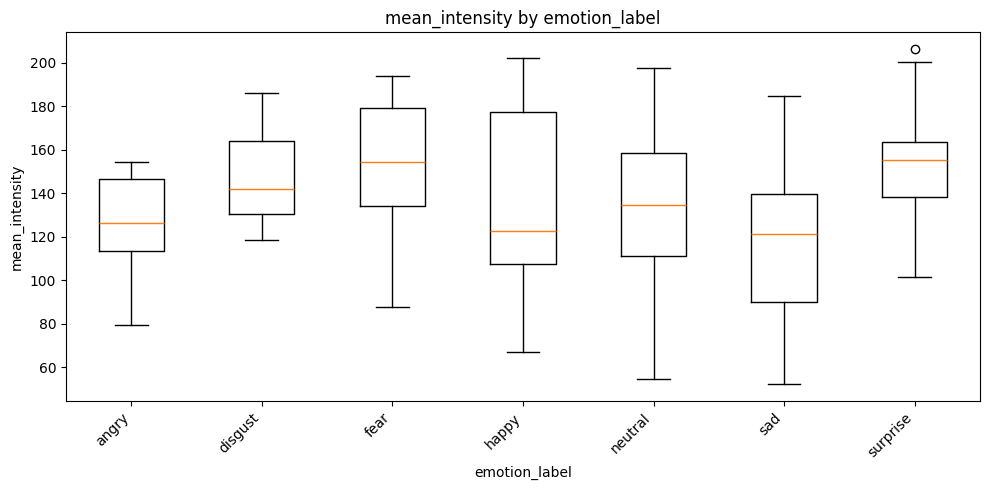

/tmp/ipykernel_1087/1952268632.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=groups)


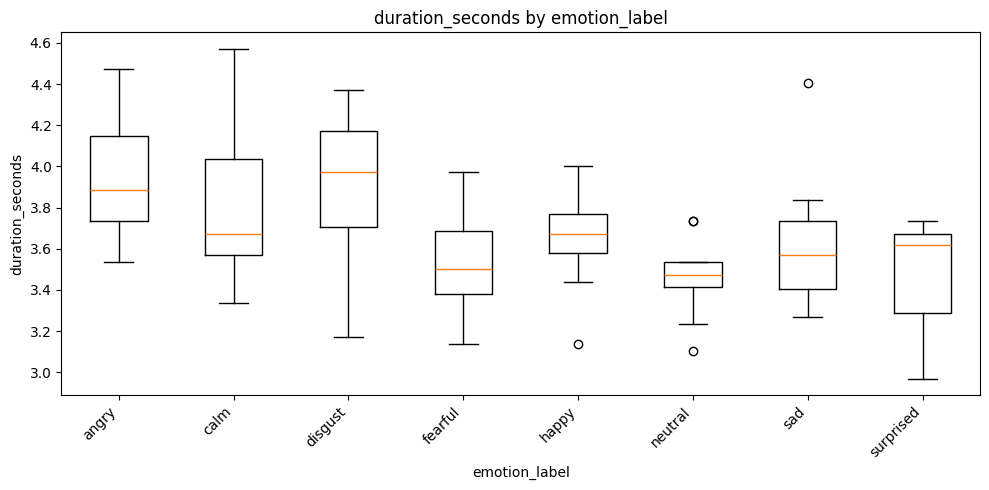

/tmp/ipykernel_1087/1952268632.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=groups)


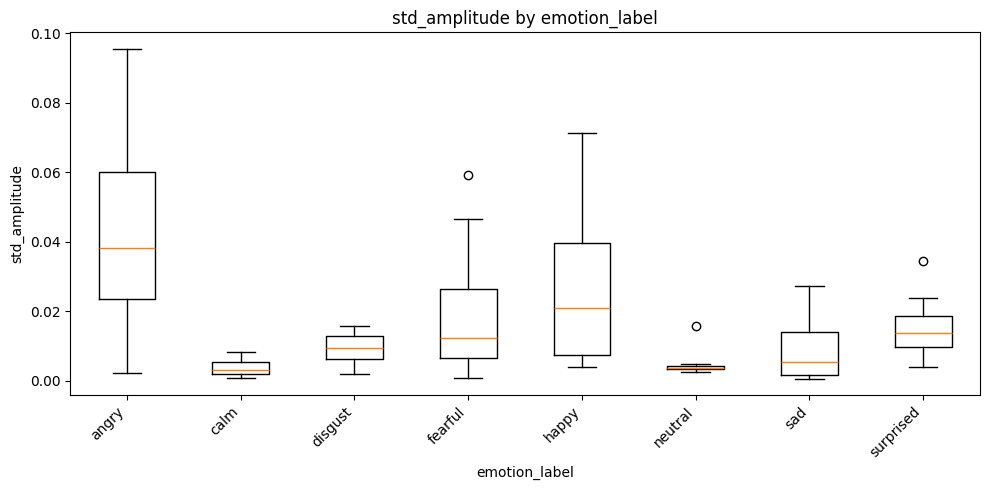


========== 3xx Q4 CHECK ==========
FER2013 class distribution (%):
emotion_label
angry       13.915497
disgust      1.518688
fear        14.270786
happy       25.131492
neutral     17.294228
sad         16.823992
surprise    11.045317
Name: count, dtype: float64
Sum: 100.0

RAVDESS class distribution (%):
emotion_label
angry        13.333333
calm         13.333333
disgust      13.333333
fearful      13.333333
happy        13.333333
neutral       6.666667
sad          13.333333
surprised    13.333333
Name: count, dtype: float64
Sum: 100.0

Audio-duration outliers: 1
   emotion_label  duration_seconds
61          calm          4.571229

========== 5xx Q4 CHECK ==========
Pairwise KS-test results:
    class_a    class_b  ks_statistic   p_value
6     angry  surprised      0.750000  0.002798
4     angry    neutral      0.750000  0.000664
17  disgust  surprised      0.666667  0.018211
15  disgust    neutral      0.666667  0.006733
22    happy    neutral      0.600000  0.052448
16  disgust  

In [127]:
# You should NOT change this code cell.
# Q4: Exploratory Data Analysis demo and sanity checks.

# Use a small sample so this runs quickly on Colab.
image_stats_df = image_eda_stats(
    fer2013_metadata,
    n_samples=100,
    rng_seed=42
)

audio_stats_df = audio_eda_stats(
    ravdess_metadata,
    n_samples=100,
    rng_seed=42
)

print("========== FER2013 IMAGE EDA ==========")
print("Image EDA DataFrame shape:", image_stats_df.shape)
print(image_stats_df.head())

print("\nImage summary statistics:")
print(
    image_stats_df[
        ["mean_intensity", "std_intensity", "image_height", "image_width"]
    ].describe()
)

print("\n========== RAVDESS AUDIO EDA ==========")
print("Audio EDA DataFrame shape:", audio_stats_df.shape)
print(audio_stats_df.head())

print("\nAudio summary statistics:")
print(
    audio_stats_df[
        ["duration_seconds", "mean_amplitude", "std_amplitude", "sampling_rate"]
    ].describe()
)

# Compulsory Q4 plots
plot_stat_distribution(
    image_stats_df,
    stat_column="mean_intensity",
    group_column="emotion_label"
)

plot_stat_distribution(
    audio_stats_df,
    stat_column="duration_seconds",
    group_column="emotion_label"
)

plot_stat_distribution(
    audio_stats_df,
    stat_column="std_amplitude",
    group_column="emotion_label"
)

# -------------------------------------------------------------------------
# 3xx-specific checks
# -------------------------------------------------------------------------
print("\n========== 3xx Q4 CHECK ==========")

image_class_percentages = class_balance_report(
    fer2013_metadata,
    label_column="emotion_label"
)

audio_class_percentages = class_balance_report(
    ravdess_metadata,
    label_column="emotion_label"
)

print("FER2013 class distribution (%):")
print(image_class_percentages.sort_index())
print("Sum:", image_class_percentages.sum())

print("\nRAVDESS class distribution (%):")
print(audio_class_percentages.sort_index())
print("Sum:", audio_class_percentages.sum())

audio_outlier_mask = flag_outliers_iqr(
    audio_stats_df,
    stat_column="duration_seconds"
)

print("\nAudio-duration outliers:", int(audio_outlier_mask.sum()))
print(
    audio_stats_df.loc[
        audio_outlier_mask,
        ["emotion_label", "duration_seconds"]
    ].head(10)
)

# -------------------------------------------------------------------------
# 5xx-specific checks
# -------------------------------------------------------------------------
print("\n========== 5xx Q4 CHECK ==========")

ks_results_df = ks_test_across_classes(
    audio_stats_df,
    stat_column="duration_seconds",
    group_column="emotion_label"
)

print("Pairwise KS-test results:")
print(ks_results_df.sort_values("ks_statistic", ascending=False).head(10))

class_a, class_b, ks_statistic = most_shifted_class_pair(ks_results_df)

print("\nMost shifted emotion pair:")
print("class_a:", class_a)
print("class_b:", class_b)
print("KS statistic:", round(ks_statistic, 4))

# `q5`: Empirical Risk Minimization and Probability Foundations

## Part A (Compulsory): Random Variables, Joint Distributions, Expectation

1. `compute_marginal(joint_probs, axis)` — marginal from joint table.
2. `compute_conditional(joint_probs, given_axis)` — conditional distribution.
3. `compute_expectation(values, probs)` — E[X].
4. `compute_expectation_of_function(values, probs, func)` — E[f(X)].

## Part B: Tiered ERM Task

### `q5_3xx`
1. `squared_loss(y_true, y_pred)`
2. `expected_risk(w, x_values, y_values, joint_probs)` — true expected risk via full joint table.
3. `empirical_risk(w, x_samples, y_samples)` — sample average loss.
4. `find_best_w(x_samples, y_samples, w_grid)` — grid-search ERM.

### `q5_5xx`
1–3. Same as 3xx.
4. `risk_gap_vs_sample_size(w, x_values, y_values, joint_probs, sample_sizes, num_trials, rng_seed)` — average |empirical - expected risk| per sample size.
5. `capacity_vs_risk(x_samples, y_samples, degrees)` — training MSE per polynomial degree (via `np.polyfit`).

## Grading [Total: 2 points]

| Task | Marks |
|---|---:|
| `q5a`: `compute_marginal` | 0.10 |
| `q5b`: `compute_conditional` | 0.15 |
| `q5c`: `compute_expectation` | 0.10 |
| `q5d`: `compute_expectation_of_function` | 0.15 |
| **Part A total** | **0.50** |

### Part B: 3xx [1.5 marks]

| Task | Marks |
|---|---:|
| `q5e`: `squared_loss` | 0.15 |
| `q5f`: `expected_risk` | 0.50 |
| `q5g`: `empirical_risk` | 0.35 |
| `q5h`: `find_best_w` | 0.50 |
| **Part B total** | **1.50** |

### Part B: 5xx variant [1.5 marks]

| Task | Marks |
|---|---:|
| `q5e`: `squared_loss` | 0.10 |
| `q5f`: `expected_risk` | 0.30 |
| `q5g`: `empirical_risk` | 0.20 |
| `q5h`: `risk_gap_vs_sample_size` | 0.45 |
| `q5i`: `capacity_vs_risk` | 0.45 |
| **Part B total** | **1.50** |



In [128]:
def compute_marginal(joint_probs, axis):
    """0 -> marginalize over X returns P(Y); 1 -> marginalize over Y returns P(X)."""
    # YOUR CODE HERE
    return joint_probs.sum(axis=axis)
    raise NotImplementedError("compute_marginal is not implemented yet.")

def compute_conditional(joint_probs, given_axis):
    """given_axis=0 -> P(Y|X); given_axis=1 -> P(X|Y)."""
    # YOUR CODE HERE
    if given_axis == 0:
        p_x = joint_probs.sum(axis=1, keepdims=True)
        p_x_safe = np.where(p_x == 0, 1.0, p_x)
        return joint_probs / p_x_safe
    else:
        p_y = joint_probs.sum(axis=0, keepdims=True)
        p_y_safe = np.where(p_y == 0, 1.0, p_y)
        return joint_probs / p_y_safe
    raise NotImplementedError("compute_conditional is not implemented yet.")

def compute_expectation(values, probs):
    """E[X] = sum(values * probs)."""
    # YOUR CODE HERE
    return float(np.sum(values * probs))
    raise NotImplementedError("compute_expectation is not implemented yet.")

def compute_expectation_of_function(values, probs, func):
    """E[f(X)] = sum(func(values) * probs)."""
    # YOUR CODE HERE
    return float(np.sum(func(values) * probs))
    raise NotImplementedError("compute_expectation_of_function is not implemented yet.")

def squared_loss(y_true, y_pred):
    """(y_true - y_pred) ** 2."""
    # YOUR CODE HERE
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return (y_true - y_pred) ** 2
    raise NotImplementedError("squared_loss is not implemented yet.")

def expected_risk(w, x_values, y_values, joint_probs):
    """True expected risk R(w) via full joint table."""
    # YOUR CODE HERE
    x_values = np.asarray(x_values, dtype=np.float64)
    y_values = np.asarray(y_values, dtype=np.float64)

    preds = w * x_values  # shape (n_x,)
    losses = squared_loss(y_values[None, :], preds[:, None])  # shape (n_x, n_y)

    return float(np.sum(joint_probs * losses))
    raise NotImplementedError("expected_risk is not implemented yet.")

def empirical_risk(w, x_samples, y_samples):
    """(1/n) * sum(loss(y_i, w*x_i))."""
    # YOUR CODE HERE
    x_samples = np.asarray(x_samples, dtype=np.float64)
    y_samples = np.asarray(y_samples, dtype=np.float64)
    preds = w * x_samples
    return float(np.mean(squared_loss(y_samples, preds)))
    raise NotImplementedError("empirical_risk is not implemented yet.")

# q5_3xx
def find_best_w(x_samples, y_samples, w_grid):
    """Grid-search ERM: w in w_grid minimizing empirical risk."""
    # YOUR CODE HERE
    risks = np.array([empirical_risk(w, x_samples, y_samples) for w in w_grid])
    best_idx = np.argmin(risks)
    return w_grid[best_idx]
    raise NotImplementedError("find_best_w is not implemented yet.")

# q5_5xx
def risk_gap_vs_sample_size(w, x_values, y_values, joint_probs, sample_sizes, num_trials, rng_seed):
    """Average |empirical_risk - expected_risk| per sample size."""
    # YOUR CODE HERE
    rng = np.random.default_rng(rng_seed)

    x_values = np.asarray(x_values, dtype=np.float64)
    y_values = np.asarray(y_values, dtype=np.float64)

    n_x, n_y = joint_probs.shape
    flat_probs = joint_probs.flatten()

    true_risk = expected_risk(w, x_values, y_values, joint_probs)

    avg_gaps = []
    for n in sample_sizes:
        gaps = []
        for _ in range(num_trials):
            sample_indices = rng.choice(np.arange(n_x * n_y), size=int(n), p=flat_probs)
            x_idx = sample_indices // n_y
            y_idx = sample_indices % n_y

            x_samples = x_values[x_idx]
            y_samples = y_values[y_idx]

            emp_risk = empirical_risk(w, x_samples, y_samples)
            gaps.append(abs(emp_risk - true_risk))

        avg_gaps.append(float(np.mean(gaps)))

    return np.array(avg_gaps)
    raise NotImplementedError("risk_gap_vs_sample_size is not implemented yet.")

def capacity_vs_risk(x_samples, y_samples, degrees):
    """Training MSE per polynomial degree (np.polyfit)."""
    # YOUR CODE HERE
    x_samples = np.asarray(x_samples, dtype=np.float64)
    y_samples = np.asarray(y_samples, dtype=np.float64)

    training_risks = []
    for degree in degrees:
        coeffs = np.polyfit(x_samples, y_samples, degree)
        preds = np.polyval(coeffs, x_samples)
        mse = float(np.mean((y_samples - preds) ** 2))
        training_risks.append(mse)

    return np.array(training_risks)
    raise NotImplementedError("capacity_vs_risk is not implemented yet.")


========== Q5 PROBABILITY CHECK ==========
Joint probabilities sum: 1.0
P(X): [0.12222222 0.25555556 0.31111111 0.31111111]
P(Y): [0.07777778 0.2        0.31111111 0.26666667 0.14444444]
P(X) sum: 1.0
P(Y) sum: 1.0000000000000002

P(Y | X) row sums: [1. 1. 1. 1.]
P(X | Y) column sums: [1. 1. 1. 1. 1.]

E[X]: 2.811111111111111
E[X^2]: 8.922222222222222

========== Q5 ERM CHECK ==========
w = 1.0
Expected risk R(w): 1.5444444444444447
Empirical risk R_hat_n(w), n=200: 1.74
Absolute risk gap: 0.19555555555555526

========== 3xx Q5 CHECK ==========
Best w found by grid-search ERM: 1.1
Empirical risk at best w: 1.669

========== 5xx Q5 CHECK ==========
Sample sizes: [  10   25   50  100  250  500 1000]
Average absolute risk gaps: [0.70977778 0.39511111 0.30777778 0.19397778 0.12945778 0.10046667
 0.06445556]


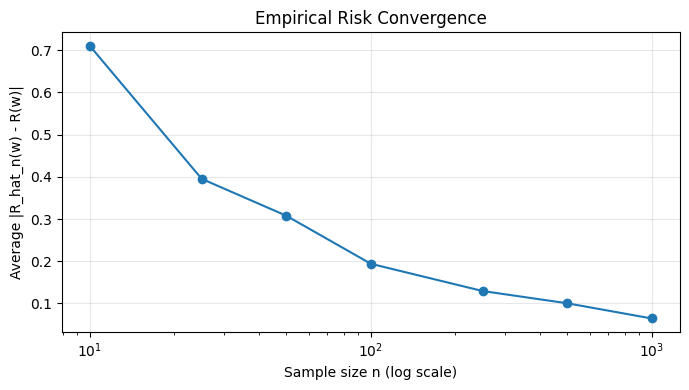

/tmp/ipykernel_1087/1126500418.py:111: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_samples, y_samples, degree)
/tmp/ipykernel_1087/1126500418.py:111: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_samples, y_samples, degree)
/tmp/ipykernel_1087/1126500418.py:111: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_samples, y_samples, degree)


Polynomial degrees: [1, 2, 3, 5, 8, 12]
Training MSE per degree: [1.06175563 1.0524606  1.04982578 1.04982578 1.04982578 1.04982578]


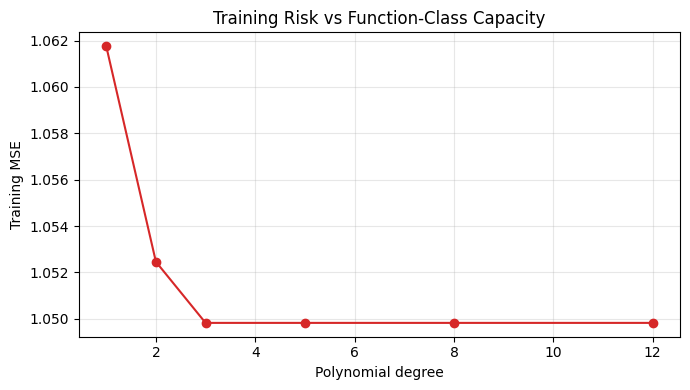

In [129]:
# You should NOT change this code cell.
# Q5: Expected risk, empirical risk, and ERM demo.

np.random.seed(42)

# X has 4 possible values; Y has 5 possible values.
x_values = np.array([1.0, 2.0, 3.0, 4.0])
y_values = np.array([1.0, 2.0, 3.0, 4.0, 5.0])

# A valid joint distribution P(X, Y)
raw_joint = np.array([
    [0.02, 0.04, 0.03, 0.01, 0.01],
    [0.03, 0.08, 0.07, 0.03, 0.02],
    [0.01, 0.04, 0.12, 0.08, 0.03],
    [0.01, 0.02, 0.06, 0.12, 0.07],
], dtype=np.float64)

joint_probs = raw_joint / raw_joint.sum()

# -------------------------------------------------------------------------
# Probability checks
# -------------------------------------------------------------------------
p_x = compute_marginal(joint_probs, axis=1)
p_y = compute_marginal(joint_probs, axis=0)

p_y_given_x = compute_conditional(joint_probs, given_axis=0)
p_x_given_y = compute_conditional(joint_probs, given_axis=1)

print("========== Q5 PROBABILITY CHECK ==========")
print("Joint probabilities sum:", joint_probs.sum())
print("P(X):", p_x)
print("P(Y):", p_y)
print("P(X) sum:", p_x.sum())
print("P(Y) sum:", p_y.sum())

print("\nP(Y | X) row sums:", p_y_given_x.sum(axis=1))
print("P(X | Y) column sums:", p_x_given_y.sum(axis=0))

expected_x = compute_expectation(x_values, p_x)
expected_x_squared = compute_expectation_of_function(
    x_values,
    p_x,
    lambda x: x ** 2
)

print("\nE[X]:", expected_x)
print("E[X^2]:", expected_x_squared)

# -------------------------------------------------------------------------
# Generate an i.i.d. data sample from P(X,Y)
# -------------------------------------------------------------------------
n_x, n_y = joint_probs.shape
flat_probs = joint_probs.flatten()

sample_size = 200
sample_indices = np.random.choice(
    np.arange(n_x * n_y),
    size=sample_size,
    p=flat_probs
)

x_indices = sample_indices // n_y
y_indices = sample_indices % n_y

x_samples = x_values[x_indices]
y_samples = y_values[y_indices]

# -------------------------------------------------------------------------
# ERM checks
# -------------------------------------------------------------------------
w = 1.0

true_risk = expected_risk(
    w,
    x_values,
    y_values,
    joint_probs
)

sample_risk = empirical_risk(
    w,
    x_samples,
    y_samples
)

print("\n========== Q5 ERM CHECK ==========")
print("w =", w)
print("Expected risk R(w):", true_risk)
print("Empirical risk R_hat_n(w), n=200:", sample_risk)
print("Absolute risk gap:", abs(true_risk - sample_risk))

# 3xx: grid search
w_grid = np.linspace(-2.0, 3.0, 101)
best_w = find_best_w(x_samples, y_samples, w_grid)

print("\n========== 3xx Q5 CHECK ==========")
print("Best w found by grid-search ERM:", best_w)
print("Empirical risk at best w:", empirical_risk(best_w, x_samples, y_samples))

# 5xx: convergence of empirical risk to expected risk
sample_sizes = np.array([10, 25, 50, 100, 250, 500, 1000])

risk_gaps = risk_gap_vs_sample_size(
    w=1.0,
    x_values=x_values,
    y_values=y_values,
    joint_probs=joint_probs,
    sample_sizes=sample_sizes,
    num_trials=50,
    rng_seed=42
)

print("\n========== 5xx Q5 CHECK ==========")
print("Sample sizes:", sample_sizes)
print("Average absolute risk gaps:", risk_gaps)

plt.figure(figsize=(7, 4))
plt.plot(sample_sizes, risk_gaps, marker="o")
plt.xscale("log")
plt.title("Empirical Risk Convergence")
plt.xlabel("Sample size n (log scale)")
plt.ylabel("Average |R_hat_n(w) - R(w)|")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Model capacity demonstration
degrees = [1, 2, 3, 5, 8, 12]
training_risks = capacity_vs_risk(x_samples, y_samples, degrees)

print("Polynomial degrees:", degrees)
print("Training MSE per degree:", training_risks)

plt.figure(figsize=(7, 4))
plt.plot(degrees, training_risks, marker="o", color="tab:red")
plt.title("Training Risk vs Function-Class Capacity")
plt.xlabel("Polynomial degree")
plt.ylabel("Training MSE")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# `q6`: Linear Regression on Extracted Audio/Image Features

## Part A (Compulsory): Systems of Linear Equations

1. `is_solvable(A)` — bool, True if invertible (use matrix_rank).
2. `solve_linear_system(A, b)` — solve Ax=b, fallback to lstsq if singular.
3. `condition_number(A)` — largest/smallest singular value ratio (via SVD).

## Part B: Tiered Task

### `q6_3xx`: Univariate Linear Regression
1. `add_bias_column(x)` — prepend column of ones.
2. `fit_univariate_linear_regression(x, y)` — normal equations w=(X^T X)^-1 X^T y.
3. `predict_univariate(x, w)` — w0 + w1*x.
4. `mean_squared_error(y_true, y_pred)`.

### `q6_5xx`: Multivariate + Ridge Regression
1. `add_bias_column(X)` — 2D version.
2. `fit_multivariate_linear_regression(X, y, reg_lambda=0.0)` — ridge normal equations, bias NOT regularized.
3. `predict_multivariate(X, w)`.
4. `mean_squared_error(y_true, y_pred)`.
5. `regularization_path(X, y, lambdas)` — returns (train_mse_array, condition_number_array) per lambda.

## Grading [Total: 3 points]

### Part A: Systems of Linear Equations — Compulsory [0.75 points]

| Question | Function | Marks |
|---|---|---:|
| `1` | `is_solvable(A)` | 0.20 |
| `2` | `solve_linear_system(A, b)` | 0.35 |
| `3` | `condition_number(A)` | 0.20 |
|  | **Part A Total** | **0.75** |

### Part B: 3xx — Univariate Linear Regression [2.25 points]

| Question | Function | Marks |
|---|---|---:|
| `1` | `add_bias_column(x)` | 0.30 |
| `2` | `fit_univariate_linear_regression(x, y)` | 0.90 |
| `3` | `predict_univariate(x, w)` | 0.45 |
| `4` | `mean_squared_error(y_true, y_pred)` | 0.60 |
|  | **Part B Total** | **2.25** |

### Part B: 5xx — Multivariate Ridge Regression [2.25 points]

| Question | Function / Task | Marks |
|---|---|---:|
| `1` | `add_bias_column(X)` | 0.35 |
| `2` | `fit_multivariate_linear_regression(X, y, reg_lambda=0.0)` | 0.75 |
| `3` | `predict_multivariate(X, w)` | 0.30 |
| `4` | `mean_squared_error(y_true, y_pred)` | 0.30 |
| `5` | `regularization_path(X, y, lambdas)` | 0.55 |
|  | **Part B Total** | **2.25** |

No partial points will be awarded for any individual programming function. Each
function must run without errors on hidden test cases to receive its assigned
marks.

In [130]:
def is_solvable(A):
    """True if A is invertible (non-singular)."""
    # YOUR CODE HERE
    A = np.asarray(A, dtype=np.float64)
    return np.linalg.matrix_rank(A) == A.shape[0]
    raise NotImplementedError("is_solvable is not implemented yet.")

def solve_linear_system(A, b):
    """Solve Ax=b; fallback to least-squares if singular."""
    # YOUR CODE HERE
    A = np.asarray(A, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)

    if is_solvable(A):
        return np.linalg.solve(A, b)
    else:
        solution, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
        return solution
    raise NotImplementedError("solve_linear_system is not implemented yet.")

def condition_number(A):
    """Ratio of largest to smallest singular value."""
    # YOUR CODE HERE
    A = np.asarray(A, dtype=np.float64)
    singular_values = np.linalg.svd(A, compute_uv=False)

    min_sv = singular_values[-1]
    max_sv = singular_values[0]

    if min_sv == 0:
        return np.inf

    return float(max_sv / min_sv)
    raise NotImplementedError("condition_number is not implemented yet.")

# q6_3xx
def add_bias_column(x):
    """Prepend column of ones. Works for 1D (n,) -> (n,2) or 2D (n,d) -> (n,d+1)."""
    # YOUR CODE HERE
    x = np.asarray(x, dtype=np.float64)
    if x.ndim == 1:
        x = x.reshape(-1, 1)
    ones = np.ones((x.shape[0], 1), dtype=np.float64)
    return np.hstack([ones, x])
    raise NotImplementedError("add_bias_column is not implemented yet.")

def fit_univariate_linear_regression(x, y):
    """Fit y_hat = w0 + w1*x via normal equations. Returns [w0, w1]."""
    # YOUR CODE HERE
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    X = add_bias_column(x)
    w = np.linalg.lstsq(X, y, rcond=None)[0]
    return w
    raise NotImplementedError("fit_univariate_linear_regression is not implemented yet.")

def predict_univariate(x, w):
    """Predict w0 + w1*x."""
    # YOUR CODE HERE
    x = np.asarray(x, dtype=np.float64)
    X = add_bias_column(x)
    return X @ w
    raise NotImplementedError("predict_univariate is not implemented yet.")

def mean_squared_error(y_true, y_pred):
    """Mean squared error."""
    # YOUR CODE HERE
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return float(np.mean((y_true - y_pred) ** 2))
    raise NotImplementedError("mean_squared_error is not implemented yet.")

# q6_5xx
def fit_multivariate_linear_regression(X, y, reg_lambda=0.0):
    """Ridge regression, bias term NOT regularized. Returns w of shape (d+1,)."""
    # YOUR CODE HERE
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    X_bias = add_bias_column(X)
    n_features = X_bias.shape[1]

    reg_matrix = reg_lambda * np.eye(n_features)
    reg_matrix[0, 0] = 0.0  # do not regularize bias

    A = X_bias.T @ X_bias + reg_matrix
    b = X_bias.T @ y

    w = np.linalg.solve(A, b) if is_solvable(A) else np.linalg.lstsq(A, b, rcond=None)[0]
    return w
    raise NotImplementedError("fit_multivariate_linear_regression is not implemented yet.")

def predict_multivariate(X, w):
    """Predict Xw after adding bias column."""
    # YOUR CODE HERE
    X = np.asarray(X, dtype=np.float64)
    X_bias = add_bias_column(X)
    return X_bias @ w
    raise NotImplementedError("predict_multivariate is not implemented yet.")

def regularization_path(X, y, lambdas):
    """Returns (train_mse_array, condition_number_array), one value per lambda."""
    # YOUR CODE HERE
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    X_bias = add_bias_column(X)

    train_mse_values = []
    condition_numbers = []

    for reg_lambda in lambdas:
        w = fit_multivariate_linear_regression(X, y, reg_lambda=reg_lambda)
        preds = predict_multivariate(X, w)
        mse = mean_squared_error(y, preds)

        n_features = X_bias.shape[1]
        reg_matrix = reg_lambda * np.eye(n_features)
        reg_matrix[0, 0] = 0.0
        A = X_bias.T @ X_bias + reg_matrix
        cond = condition_number(A)

        train_mse_values.append(mse)
        condition_numbers.append(cond)

    return np.array(train_mse_values), np.array(condition_numbers)
    raise NotImplementedError("regularization_path is not implemented yet.")



========== Q6 DATA CHECK ==========
Number of RAVDESS samples: 100
ZCR shape: (100,)
Energy shape: (100,)
Intensity target shape: (100,)

========== Q6 LINEAR-SYSTEM CHECK ==========
A:
 [[2. 1.]
 [1. 3.]]
b: [ 5. 10.]
Is A solvable? True
Solution x to Ax=b: [1. 3.]
Condition number of A: 2.6180339887498953

Is singular A solvable? False
Least-squares solution for singular system: [0.6 1.2]

========== 3xx Q6 CHECK ==========
Univariate weights [w0, w1]: [ 0.01333024 -0.03496408]
Univariate training MSE: 2.1473875674284148e-05


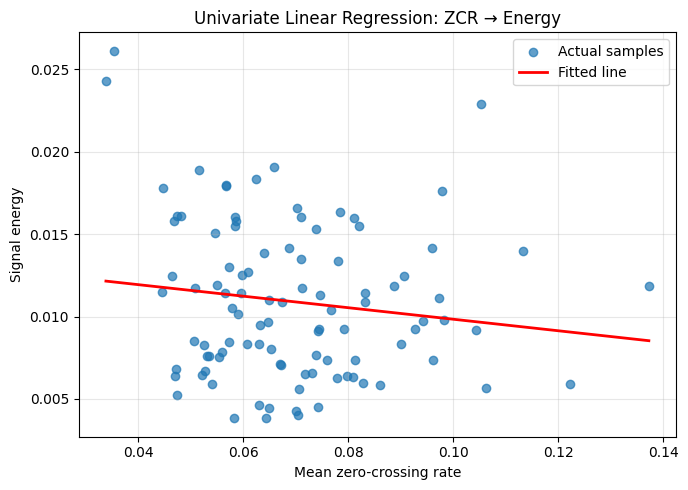


========== 5xx Q6 CHECK ==========
Multivariate X shape: (100, 4)
Ridge weights: [-0.12865791  0.11809358 -0.01325937  0.4195412  -0.04378066]
Ridge training MSE: 0.2205520462009906

Lambdas: [0.e+00 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
Training MSE: [0.21359018 0.21531901 0.21592528 0.21860904 0.22055205 0.22586325
 0.24026311]
Condition numbers: [1.68239552e+07 1.36129282e+06 1.46822051e+05 1.47993320e+04
 1.76545839e+03 1.02549072e+03 2.22089041e+02]


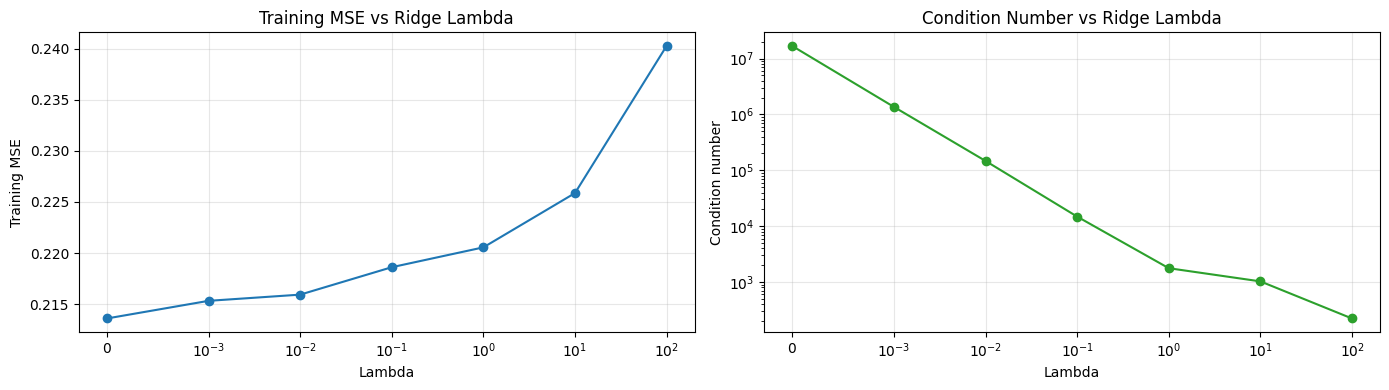

In [131]:
# You should NOT change this code cell.
# Q6: Linear regression demo using real RAVDESS audio statistics.

def extract_simple_audio_features(audio, sr):
    """
    Helper used only in the fixed test cell.
    Returns four scalar features:
      1. ZCR mean
      2. Energy
      3. Duration
      4. Mean absolute amplitude
    """
    audio = np.asarray(audio, dtype=np.float64)

    zcr_values = get_zero_crossing_rate(audio)
    zcr_mean = float(np.mean(zcr_values))

    energy = float(np.mean(audio ** 2))
    duration = float(len(audio) / sr)
    mean_abs_amplitude = float(np.mean(np.abs(audio)))

    return zcr_mean, energy, duration, mean_abs_amplitude


# Select a manageable subset; loading all 1,440 files is not required.
demo_rows = ravdess_metadata.sample(
    n=min(100, len(ravdess_metadata)),
    random_state=42
)

zcr_values = []
energy_values = []
duration_values = []
mean_amplitude_values = []
intensity_targets = []

for _, row in demo_rows.iterrows():
    sr, audio = load_audio(row["filepath"])
    audio = normalize_audio(audio)

    zcr, energy, duration, mean_amp = extract_simple_audio_features(audio, sr)

    zcr_values.append(zcr)
    energy_values.append(energy)
    duration_values.append(duration)
    mean_amplitude_values.append(mean_amp)

    # RAVDESS intensity code: 1 = normal, 2 = strong.
    intensity_targets.append(float(row["intensity_code"]))

zcr_values = np.array(zcr_values)
energy_values = np.array(energy_values)
duration_values = np.array(duration_values)
mean_amplitude_values = np.array(mean_amplitude_values)
intensity_targets = np.array(intensity_targets)

print("========== Q6 DATA CHECK ==========")
print("Number of RAVDESS samples:", len(zcr_values))
print("ZCR shape:", zcr_values.shape)
print("Energy shape:", energy_values.shape)
print("Intensity target shape:", intensity_targets.shape)

# -------------------------------------------------------------------------
# Part A: Linear-system checks
# -------------------------------------------------------------------------
A = np.array([
    [2.0, 1.0],
    [1.0, 3.0]
])

b = np.array([5.0, 10.0])

print("\n========== Q6 LINEAR-SYSTEM CHECK ==========")
print("A:\n", A)
print("b:", b)
print("Is A solvable?", is_solvable(A))
print("Solution x to Ax=b:", solve_linear_system(A, b))
print("Condition number of A:", condition_number(A))

# Singular matrix test: should use least squares.
A_singular = np.array([
    [1.0, 2.0],
    [2.0, 4.0]
])

b_singular = np.array([3.0, 6.0])

print("\nIs singular A solvable?", is_solvable(A_singular))
print(
    "Least-squares solution for singular system:",
    solve_linear_system(A_singular, b_singular)
)

# -------------------------------------------------------------------------
# 3xx: univariate regression
# Input x = ZCR; target y = signal energy.
# -------------------------------------------------------------------------
w_univariate = fit_univariate_linear_regression(
    zcr_values,
    energy_values
)

energy_predictions = predict_univariate(
    zcr_values,
    w_univariate
)

univariate_mse = mean_squared_error(
    energy_values,
    energy_predictions
)

print("\n========== 3xx Q6 CHECK ==========")
print("Univariate weights [w0, w1]:", w_univariate)
print("Univariate training MSE:", univariate_mse)

plt.figure(figsize=(7, 5))
plt.scatter(zcr_values, energy_values, alpha=0.7, label="Actual samples")

sorted_indices = np.argsort(zcr_values)
plt.plot(
    zcr_values[sorted_indices],
    energy_predictions[sorted_indices],
    color="red",
    linewidth=2,
    label="Fitted line"
)

plt.title("Univariate Linear Regression: ZCR → Energy")
plt.xlabel("Mean zero-crossing rate")
plt.ylabel("Signal energy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 5xx: multivariate ridge regression
# Input features: ZCR, energy, duration, mean absolute amplitude.
# Target: RAVDESS intensity code (1 normal, 2 strong).
# -------------------------------------------------------------------------
X_multivariate = np.column_stack([
    zcr_values,
    energy_values,
    duration_values,
    mean_amplitude_values
])

y_multivariate = intensity_targets

ridge_weights = fit_multivariate_linear_regression(
    X_multivariate,
    y_multivariate,
    reg_lambda=1.0
)

intensity_predictions = predict_multivariate(
    X_multivariate,
    ridge_weights
)

ridge_mse = mean_squared_error(
    y_multivariate,
    intensity_predictions
)

print("\n========== 5xx Q6 CHECK ==========")
print("Multivariate X shape:", X_multivariate.shape)
print("Ridge weights:", ridge_weights)
print("Ridge training MSE:", ridge_mse)

lambdas = np.array([0.0, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0])

training_mse_values, condition_numbers = regularization_path(
    X_multivariate,
    y_multivariate,
    lambdas
)

print("\nLambdas:", lambdas)
print("Training MSE:", training_mse_values)
print("Condition numbers:", condition_numbers)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(lambdas, training_mse_values, marker="o")
axes[0].set_xscale("symlog", linthresh=0.001)
axes[0].set_title("Training MSE vs Ridge Lambda")
axes[0].set_xlabel("Lambda")
axes[0].set_ylabel("Training MSE")
axes[0].grid(True, alpha=0.3)

axes[1].plot(lambdas, condition_numbers, marker="o", color="tab:green")
axes[1].set_xscale("symlog", linthresh=0.001)
axes[1].set_yscale("log")
axes[1].set_title("Condition Number vs Ridge Lambda")
axes[1].set_xlabel("Lambda")
axes[1].set_ylabel("Condition number")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# `bonus`: Multimodal Fusion Classification (Extra Credit)

## Part A (Compulsory): Paired Multimodal Dataset

1. `build_paired_dataset(ravdess_metadata, fer2013_metadata, common_emotions, n_per_emotion, rng_seed)` — match RAVDESS audio to random FER2013 image of same emotion (handle "surprised" vs "surprise" naming). Returns DataFrame (audio_filepath, image_filepath, emotion_label).
2. `extract_paired_features(paired_df)` — extract+concat aggregated audio(MFCC) + image(hist+LBP) features. Returns (X, y).

## Part B: Tiered

### `bonus_3xx` (0.7 point): One-vs-Rest Linear Classifier
3. `one_hot_encode_labels(y)` — (Y_onehot, class_names).
4. `train_ovr_linear_classifier(X, Y_onehot, reg_lambda=1.0)` — one ridge model per class. Returns W (n_features+1, n_classes).
5. `predict_ovr(X, W, class_names)` — argmax score prediction.

### `bonus_5xx` (0.7 point): Cross-Validated Model Selection
6. `k_fold_cross_validate(X, y, k, reg_lambda, rng_seed)` — per-fold accuracy array.
7. `select_best_lambda(X, y, lambdas, k, rng_seed)` — (best_lambda, mean_accuracies).

## Grading [Total: 1 points — Extra Credit]

### Part A: Paired Multimodal Dataset — Compulsory [0.3 point]

| Question | Function | Marks |
|---|---|---:|
| `1` | `build_paired_dataset(ravdess_metadata, fer2013_metadata, common_emotions, n_per_emotion, rng_seed)` | 0.1 |
| `2` | `extract_paired_features(paired_df)` | 0.2 |
|  | **Part A Total** | **0.3** |

### Part B: 3xx — One-vs-Rest Linear Classifier [0.7 points]

| Question | Function | Marks |
|---|---|---:|
| `3` | `one_hot_encode_labels(y)` | 0.1 |
| `4` | `train_ovr_linear_classifier(X, Y_onehot, reg_lambda=1.0)` | 0.3 |
| `5` | `predict_ovr(X, W, class_names)` | 0.3 |
|  | **Part B Total** | **0.7** |

### Part B: 5xx — Cross-Validated Model Selection [0.7 points]

| Question | Function / Task | Marks |
|---|---|---:|
| `6` | `k_fold_cross_validate(X, y, k, reg_lambda, rng_seed)` | 0.35 |
| `7` | `select_best_lambda(X, y, lambdas, k, rng_seed)` | 0.35 |
|  | **Part B Total** | **0.7** |


No partial points will be awarded for any individual programming function. Each
function must run without errors on hidden test cases to receive its assigned
marks.

In [132]:
def build_paired_dataset(ravdess_metadata, fer2013_metadata, common_emotions, n_per_emotion, rng_seed):
    """Returns DataFrame: audio_filepath, image_filepath, emotion_label."""
    # YOUR CODE HERE
    emotion_label_map = {
        "surprised": "surprise",
        "fearful": "fear",
    }

    rng = np.random.default_rng(rng_seed)
    records = []

    for emotion in common_emotions:
        fer_emotion = emotion_label_map.get(emotion, emotion)

        ravdess_subset = ravdess_metadata[ravdess_metadata["emotion_label"] == emotion]
        fer_subset = fer2013_metadata[fer2013_metadata["emotion_label"] == fer_emotion]

        if len(ravdess_subset) == 0 or len(fer_subset) == 0:
            continue

        n = min(n_per_emotion, len(ravdess_subset))
        ravdess_indices = rng.choice(len(ravdess_subset), size=n, replace=False)
        ravdess_rows = ravdess_subset.iloc[ravdess_indices]

        fer_indices = rng.choice(len(fer_subset), size=n, replace=True)
        fer_rows = fer_subset.iloc[fer_indices]

        for audio_row, image_row in zip(ravdess_rows.itertuples(), fer_rows.itertuples()):
            records.append({
                "audio_filepath": audio_row.filepath,
                "image_filepath": image_row.filepath,
                "emotion_label": emotion,
            })

    return pd.DataFrame(records, columns=["audio_filepath", "image_filepath", "emotion_label"])

    raise NotImplementedError("build_paired_dataset is not implemented yet.")

def extract_paired_features(paired_df):
    """Returns (X, y): combined feature matrix and label array."""
    # YOUR CODE HERE
    feature_rows = []
    labels = []

    for row in paired_df.itertuples():
        sr, audio = load_audio(row.audio_filepath)
        audio = normalize_audio(audio)
        mfcc = get_mfcc(audio, sr)
        audio_features = aggregate_audio_features(mfcc)

        image = load_image(row.image_filepath)
        image = resize_image(image, size=(64, 64))
        if image.ndim == 3:
            image = image.mean(axis=2).astype(np.uint8)

        hist = get_histogram(image)
        _, lbp_hist = get_image_lbp(image)
        image_features = aggregate_image_features(hist, lbp_hist)

        combined = np.concatenate([audio_features, image_features])
        feature_rows.append(combined)
        labels.append(row.emotion_label)

    X = np.vstack(feature_rows)
    y = np.array(labels)
    return X, y

    raise NotImplementedError("extract_paired_features is not implemented yet.")

# bonus_3xx
def one_hot_encode_labels(y):
    """Returns (Y_onehot, class_names)."""
    # YOUR CODE HERE
    y = np.asarray(y)
    class_names = sorted(np.unique(y).tolist())
    class_index = {c: i for i, c in enumerate(class_names)}

    Y_onehot = np.zeros((len(y), len(class_names)), dtype=np.float64)
    for i, label in enumerate(y):
        Y_onehot[i, class_index[label]] = 1.0

    return Y_onehot, class_names
    raise NotImplementedError("one_hot_encode_labels is not implemented yet.")

def train_ovr_linear_classifier(X, Y_onehot, reg_lambda=1.0):
    """Returns W of shape (n_features+1, n_classes)."""
    # YOUR CODE HERE
    X = np.asarray(X, dtype=np.float64)
    Y_onehot = np.asarray(Y_onehot, dtype=np.float64)

    n_classes = Y_onehot.shape[1]
    weight_columns = []

    for c in range(n_classes):
        w_c = fit_multivariate_linear_regression(X, Y_onehot[:, c], reg_lambda=reg_lambda)
        weight_columns.append(w_c)

    W = np.column_stack(weight_columns)
    return W
    raise NotImplementedError("train_ovr_linear_classifier is not implemented yet.")

def predict_ovr(X, W, class_names):
    """Returns array of predicted label strings."""
    # YOUR CODE HERE
    X = np.asarray(X, dtype=np.float64)
    X_bias = add_bias_column(X)

    scores = X_bias @ W
    predicted_indices = np.argmax(scores, axis=1)

    class_names = np.asarray(class_names)
    return class_names[predicted_indices]
    raise NotImplementedError("predict_ovr is not implemented yet.")

# bonus_5xx
def k_fold_cross_validate(X, y, k, reg_lambda, rng_seed):
    """Returns array of per-fold accuracies, length k."""
    # YOUR CODE HERE
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y)

    rng = np.random.default_rng(rng_seed)
    n = len(X)
    indices = rng.permutation(n)
    folds = np.array_split(indices, k)

    accuracies = []
    for i in range(k):
        test_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        Y_train_onehot, class_names = one_hot_encode_labels(y_train)
        W = train_ovr_linear_classifier(X_train, Y_train_onehot, reg_lambda=reg_lambda)
        y_pred = predict_ovr(X_test, W, class_names)

        accuracy = float(np.mean(y_pred == y_test))
        accuracies.append(accuracy)

    return np.array(accuracies)
    raise NotImplementedError("k_fold_cross_validate is not implemented yet.")

def select_best_lambda(X, y, lambdas, k, rng_seed):
    """Returns (best_lambda, mean_accuracies)."""
    # YOUR CODE HERE
    mean_accuracies = []

    for reg_lambda in lambdas:
        fold_accuracies = k_fold_cross_validate(X, y, k, reg_lambda, rng_seed)
        mean_accuracies.append(float(np.mean(fold_accuracies)))

    mean_accuracies = np.array(mean_accuracies)
    best_idx = np.argmax(mean_accuracies)
    best_lambda = lambdas[best_idx]

    return best_lambda, mean_accuracies
    raise NotImplementedError("select_best_lambda is not implemented yet.")



========== BONUS PAIRED DATASET CHECK ==========
Paired DataFrame shape: (70, 3)
                                      audio_filepath  \
0  ./data/ravdess/audio_speech_actors_01-24/Actor...   
1   ./data/ravdess/Actor_17/03-01-05-01-02-02-17.wav   
2  ./data/ravdess/audio_speech_actors_01-24/Actor...   
3   ./data/ravdess/Actor_18/03-01-05-02-02-02-18.wav   
4  ./data/ravdess/audio_speech_actors_01-24/Actor...   

                                     image_filepath emotion_label  
0   ./data/fer2013/train/angry/Training_2081591.jpg         angry  
1  ./data/fer2013/train/angry/Training_58852182.jpg         angry  
2  ./data/fer2013/train/angry/Training_55389585.jpg         angry  
3  ./data/fer2013/train/angry/Training_50394577.jpg         angry  
4  ./data/fer2013/train/angry/Training_97821212.jpg         angry  

Examples per emotion:
emotion_label
angry        10
disgust      10
fearful      10
happy        10
neutral      10
sad          10
surprised    10
Name: count, dtype: int64

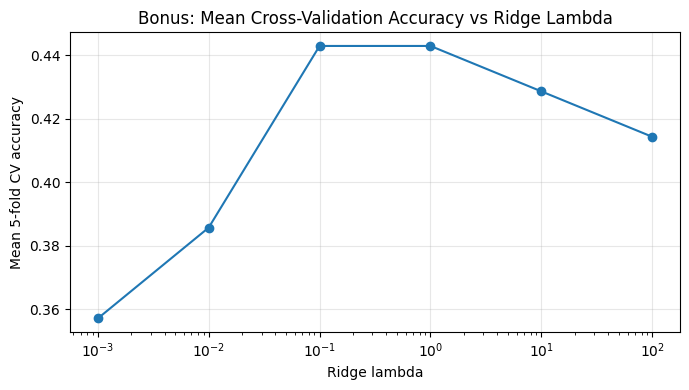

In [133]:
# You should NOT change this code cell.
# Bonus: multimodal fusion demo.

# These labels exist in RAVDESS and have matching FER2013 equivalents.
# The function should internally map:
# surprised -> surprise
# fearful -> fear
common_emotions = [
    "angry",
    "happy",
    "sad",
    "neutral",
    "surprised",
    "fearful",
    "disgust"
]

paired_df = build_paired_dataset(
    ravdess_metadata=ravdess_metadata,
    fer2013_metadata=fer2013_metadata,
    common_emotions=common_emotions,
    n_per_emotion=10,
    rng_seed=42
)

print("========== BONUS PAIRED DATASET CHECK ==========")
print("Paired DataFrame shape:", paired_df.shape)
print(paired_df.head())

print("\nExamples per emotion:")
print(paired_df["emotion_label"].value_counts().sort_index())

X_combined, y_labels = extract_paired_features(paired_df)

print("\n========== BONUS FEATURE CHECK ==========")
print("Combined feature matrix shape:", X_combined.shape)
print("Label vector shape:", y_labels.shape)
print("Unique labels:", np.unique(y_labels))

# -------------------------------------------------------------------------
# Simple held-out split: 3xx
# -------------------------------------------------------------------------
rng = np.random.default_rng(42)
indices = rng.permutation(len(X_combined))

split_index = int(0.80 * len(indices))
train_indices = indices[:split_index]
test_indices = indices[split_index:]

X_train = X_combined[train_indices]
X_test = X_combined[test_indices]

y_train = y_labels[train_indices]
y_test = y_labels[test_indices]

Y_train_onehot, class_names = one_hot_encode_labels(y_train)

W = train_ovr_linear_classifier(
    X_train,
    Y_train_onehot,
    reg_lambda=1.0
)

y_pred = predict_ovr(
    X_test,
    W,
    class_names
)

test_accuracy = np.mean(y_pred == y_test)
chance_accuracy = 1.0 / len(class_names)

print("\n========== 3xx BONUS CHECK ==========")
print("Classes:", class_names)
print("Weight matrix shape:", W.shape)
print("Test accuracy:", round(test_accuracy, 4))
print("Chance-level accuracy:", round(chance_accuracy, 4))

print("\nFirst 10 predictions:")
for true_label, predicted_label in zip(y_test[:10], y_pred[:10]):
    print(f"true: {true_label:10s} | predicted: {predicted_label}")

# -------------------------------------------------------------------------
# 5xx: Cross-validation and lambda selection
# -------------------------------------------------------------------------
lambdas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

best_lambda, mean_accuracies = select_best_lambda(
    X=X_combined,
    y=y_labels,
    lambdas=lambdas,
    k=5,
    rng_seed=42
)

print("\n========== 5xx BONUS CHECK ==========")
print("Lambdas:", lambdas)
print("Mean 5-fold CV accuracy:", mean_accuracies)
print("Best lambda:", best_lambda)

plt.figure(figsize=(7, 4))
plt.plot(lambdas, mean_accuracies, marker="o")
plt.xscale("log")
plt.title("Bonus: Mean Cross-Validation Accuracy vs Ridge Lambda")
plt.xlabel("Ridge lambda")
plt.ylabel("Mean 5-fold CV accuracy")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()